# Modeling of topics from articles collected in the systematic review (title + abstract)

This notebook implements a pipeline to extract, model, and analyze latent topics from academic publications, focusing on understanding thematic trends over time and stakeholder perspectives (legal, commercial, customer) — using current NLP tools and unsupervised topic modeling (BERTopic) to support interpretability and downstream classification.

---

## Objectives

| Task | Approach |
|------|----------|
| Predict main category label (single) | Supervised classification (e.g., BERT, XGBoost) |
| Predict subcategory labels (multi) | Multi-label classification |
| Discover emergent/unlabeled themes | Unsupervised topic modeling (BERTopic) |
| Map subcategories to topics | Co-occurrence and frequency-based alignment |
| Semantic comparison between categories | Embedding aggregation + UMAP visualization |

---

## Pipeline Overview

1. **Data ingestion and cleaning**
   - Extract titles and abstracts from `.bib` files (BibTeX format).
   - Merge and preprocess texts using `spaCy`:
     - Conversion to lowercase, removal of punctuation/digits
     - Lemmatization and custom substitutions
     - Removal of domain-specific irrelevant words

2. **Embedding generation**
   - Use `SentenceTransformer` (`all-mpnet-base-v2`) to create high-dimensional sentence embeddings.

3. **Topic modeling with BERTopic**
- Cluster documents using HDBSCAN
- Extract representative keywords with hybrid representations (KeyBERT + LLM)
- Refine the model by reducing outliers and updating topics post hoc.
- Optionally, apply hierarchical topic modeling for structure.

4. **Labeling and interpretation**
   - Generate interpretable topic labels using statistical (KeyBERT) and generative (LLM) methods
   - Clean up overlapping terms and reassign representations.

5. **Visualization and exploration**
     - Word clouds, bar charts, and UMAP projections
     - Heat maps of topic frequency by year
     - Temporal evolution through stacked bars and line charts
     - Sankey diagrams for longitudinal topic flow
- Bubble charts for tracking topic emergence

---

# Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -qqq bertopic sentence-transformers nltk  -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import spacy
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sentence_transformers import SentenceTransformer

# NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Convert .bib to .csv **[need update]**
> Final file with all references from 2000-2025 selected based on title + abstract

*note: ISO 2019 was not added*

In [ ]:
path = "/content/drive/MyDrive/TJMA LACA/artigos_pre.csv"
df = pd.read_csv(path)

df.head()

,_id,ano,volume,numero,titulo,autores,palavras_chave,abstract,referencias,link,...,Citações,pre_keywords,university,pais,location,cidade,estado,texto_documento_preprocessed,universities_translated,universities
0,68a8cad06a09251fb721014d,2025,24,1,A Flexible UHF RFID Respiratory Sensor,"['Araujo, Jéssyca I. L.', 'Serres, Georgina K....",Index Terms\\\\nFlexible tag; Metamaterial-ins...,"In this study, we developed a Radio Frequency ...","[1] M. A. Cretikos, R. Bellomo, K. Hillman, J....",https://www.scielo.br/j/jmoea/a/XHgN4VqNZCD5cC...,...,0,"flexible tag , metamaterial inspired , respira...","['Federal University of Campina Grande', 'Fede...","['Brazil', 'Brazil', 'Italy', 'Brazil', 'Brazil']","['Campina Grande, Paraíba, Brazil', 'Campina G...","[Campina Grande, Pisa, Campina Grande, Campina...","[Paraíba, Paraíba, Pisa, Paraíba, Paraíba]",federal university of campina grande; federal ...,Universidade Federal de Campina Grande; Univer...,"['universidade federal de campina grande', 'un..."
1,68a8cad36a09251fb721014e,2025,24,1,Proposition for Path Loss Prediction Models wi...,"['Jorge Júnior, Evandro M.', 'Veiga, Antônio C...",Index Terms\\\\nDifferential Evolution; Geneti...,"In this paper, it is presented a general optim...","[1] N. Faruk, S. I. Popoola, N. T. Surajudeen-...",https://www.scielo.br/j/jmoea/a/XFZhWqy65ZzgzZ...,...,0,"differential evolution , genetic algorithm , p...","['Universidade Federal de Uberlândia', 'Univer...","['Brazil', 'Brazil', 'Brazil']","['Uberlândia, Minas Gerais, Brazil', 'Uberlând...","[Uberlândia, Uberlândia, Uberlândia]","[Minas Gerais, Minas Gerais, Minas Gerais]",universidade federal de uberlandia; universida...,Universidade Federal de Uberlandia; Universida...,"['universidade federal de uberlandia', 'univer..."
2,68a8cad66a09251fb721014f,2025,24,1,A 1D-FDM Transmission Line Model for Partial D...,"['Oliveira, Rodrigo M. S. de', 'Lopes, Nathan ...",Index Terms\\\\nEffective Electrical Conductiv...,"In this paper, we present a novel numerical mo...","[1] A. Haddad and D. F. Warne, Eds., Advances ...",https://www.scielo.br/j/jmoea/a/WQxvPr4GjWVKVw...,...,0,"effective electrical conductivity , finite dif...","['Federal University of Pará', 'UFPA-ITEC', 'E...","['Brazil', 'Brazil']","['Belém, Brazil', 'Belém, Brazil']","[Belém, Belém]","[Brazil, Brazil]",federal university of para; ufpa itec; eletrob...,Universidade Federal do Pará; Universidade Fed...,"['universidade federal do para', 'universidade..."
3,68a8cad86a09251fb7210150,2025,24,1,Assessment of Planar Transmission Line with St...,"['Fonseca, Daniel A. B.', 'Costa, Luís G. da S...",Index Terms\\\\nPlanar transmission line; powe...,This study investigates the effectiveness of e...,"[1] D. K. Mahanta and O. Andrew, “Transformer ...",https://www.scielo.br/j/jmoea/a/vr67fPZqgtyFVb...,...,0,"planar transmission line , power transformer ,...","['Universidade Federal de Juiz de Fora', 'Univ...","['Brazil', 'Brazil', 'Brazil', 'Brazil', 'Braz...","['Juiz de Fora, Minas Gerais, Brazil', 'Juiz d...","[Juiz de Fora, Juiz de Fora, Juiz de Fora, Jui...","[Minas Gerais, Minas Gerais, Minas Gerais, Min...",universidade federal de juiz de fora; universi...,Universidade Federal de Juiz de Fora; Universi...,"['universidade federal de juiz de fora', 'univ..."
4,68a8cada6a09251fb7210151,2025,24,1,Space-fed Array Variations of E-shape and U-sl...,"['Deshmukh, Amit A.', 'Parvez, Adil', 'Chavali...",Index Terms\\\\nBroadband High gain microstrip...,Space-fed array comprising of E-shape or U-slo...,"[1] G. Kumar, K. P. Ray, Broadband Microstrip ...",https://www.scielo.br/j/jmoea/a/Nkr93SPpvfsMLP...,...,0,"broadband high gain microstrip antenna , shap...",['Dwarkadas Jivanlal Sanghvi College of Engine...,"['India', 'India', 'India', 'India']","['Mumbai, India', 'Mumbai, India', 'Mumbai, In...","[Mumbai, Mumbai, Mumbai, Mumbai]","[India, India, India, India]",dwarkadas jivanlal sanghvi college of engineer...,Faculdade de Engenharia Dwarkadas Jivanlal San...,['fa

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   _id                           570 non-null    object
 1   ano                           570 non-null    int64 
 2   volume                        570 non-null    int64 
 3   numero                        570 non-null    int64 
 4   titulo                        565 non-null    object
 5   autores                       570 non-null    object
 6   palavras_chave                460 non-null    object
 7   abstract                      461 non-null    object
 8   referencias                   458 non-null    object
 9   link                          570 non-null    object
 10  universidade                  490 non-null    object
 11  Citações                      570 non-null    object
 12  pre_keywords                  460 non-null    object
 13  university          

In [ ]:
df = df.rename(columns={
    "titulo": "title",
    "ano": "year",
    "autores": "author"
})

df.columns

Index(['_id', 'year', 'volume', 'numero', 'title', 'author', 'palavras_chave',
       'abstract', 'referencias', 'link', 'universidade', 'Citações',
       'pre_keywords', 'university', 'pais', 'location', 'cidade', 'estado',
       'texto_documento_preprocessed', 'universities_translated',
       'universities'],
      dtype='object')

In [ ]:
df_unlabeled = df.copy()

In [ ]:
df_unlabeled['text'] = (df_unlabeled['title'] + ". " + df_unlabeled['abstract']).fillna("")

In [ ]:
df_unlabeled

,_id,year,volume,numero,title,author,palavras_chave,abstract,referencias,link,...,pre_keywords,university,pais,location,cidade,estado,texto_documento_preprocessed,universities_translated,universities,text
0,68a8cad06a09251fb721014d,2025,24,1,A Flexible UHF RFID Respiratory Sensor,"['Araujo, Jéssyca I. L.', 'Serres, Georgina K....",Index Terms\\\\nFlexible tag; Metamaterial-ins...,"In this study, we developed a Radio Frequency ...","[1] M. A. Cretikos, R. Bellomo, K. Hillman, J....",https://www.scielo.br/j/jmoea/a/XHgN4VqNZCD5cC...,...,"flexible tag , metamaterial inspired , respira...","['Federal University of Campina Grande', 'Fede...","['Brazil', 'Brazil', 'Italy', 'Brazil', 'Brazil']","['Campina Grande, Paraíba, Brazil', 'Campina G...","[Campina Grande, Pisa, Campina Grande, Campina...","[Paraíba, Paraíba, Pisa, Paraíba, Paraíba]",federal university of campina grande; federal ...,Universidade Federal de Campina Grande; Univer...,"['universidade federal de campina grande', 'un...",A Flexible UHF RFID Respiratory Sensor. In thi...
1,68a8cad36a09251fb721014e,2025,24,1,Proposition for Path Loss Prediction Models wi...,"['Jorge Júnior, Evandro M.', 'Veiga, Antônio C...",Index Terms\\\\nDifferential Evolution; Geneti...,"In this paper, it is presented a general optim...","[1] N. Faruk, S. I. Popoola, N. T. Surajudeen-...",https://www.scielo.br/j/jmoea/a/XFZhWqy65ZzgzZ...,...,"differential evolution , genetic algorithm , p...","['Universidade Federal de Uberlândia', 'Univer...","['Brazil', 'Brazil', 'Brazil']","['Uberlândia, Minas Gerais, Brazil', 'Uberlând...","[Uberlândia, Uberlândia, Uberlândia]","[Minas Gerais, Minas Gerais, Minas Gerais]",universidade federal de uberlandia; universida...,Universidade Federal de Uberlandia; Universida...,"['universidade federal de uberlandia', 'univer...",Proposition for Path Loss Prediction Models wi...
2,68a8cad66a09251fb721014f,2025,24,1,A 1D-FDM Transmission Line Model for Partial D...,"['Oliveira, Rodrigo M. S. de', 'Lopes, Nathan ...",Index Terms\\\\nEffective Electrical Conductiv...,"In this paper, we present a novel numerical mo...","[1] A. Haddad and D. F. Warne, Eds., Advances ...",https://www.scielo.br/j/jmoea/a/WQxvPr4GjWVKVw...,...,"effective electrical conductivity , finite dif...","['Federal University of Pará', 'UFPA-ITEC', 'E...","['Brazil', 'Brazil']","['Belém, Brazil', 'Belém, Brazil']","[Belém, Belém]","[Brazil, Brazil]",federal university of para; ufpa itec; eletrob...,Universidade Federal do Pará; Universidade Fed...,"['universidade federal do para', 'universidade...",A 1D-FDM Transmission Line Model for Partial D...
3,68a8cad86a09251fb7210150,2025,24,1,Assessment of Planar Transmission Line with St...,"['Fonseca, Daniel A. B.', 'Costa, Luís G. da S...",Index Terms\\\\nPlanar transmission line; powe...,This study investigates the effectiveness of e...,"[1] D. K. Mahanta and O. Andrew, “Transformer ...",https://www.scielo.br/j/jmoea/a/vr67fPZqgtyFVb...,...,"planar transmission line , power transformer ,...","['Universidade Federal de Juiz de Fora', 'Univ...","['Brazil', 'Brazil', 'Brazil', 'Brazil', 'Braz...","['Juiz de Fora, Minas Gerais, Brazil', 'Juiz d...","[Juiz de Fora, Juiz de Fora, Juiz de Fora, Jui...","[Minas Gerais, Minas Gerais, Minas Gerais, Min...",universidade federal de juiz de fora; universi...,Universidade Federal de Juiz de Fora; Universi...,"['universidade federal de juiz de fora', 'univ...",Assessment of Planar Transmission Line with St...
4,68a8cada6a09251fb7210151,2025,24,1,Space-fed Array Variations of E-shape and U-sl...,"['Deshmukh, Amit A.', 'Parvez, Adil', 'Chavali...",Index Terms\\\\nBroadband High gain microstrip...,Space-fed array comprising of E-shape or U-slo...,"[1] G. Kumar, K. P. Ray, Broadband Microstrip ...",https://www.scielo.br/j/jmoea/a/Nkr93SPpvfsMLP...,...,"broadband high gain microstrip antenna , shap...",['Dwarkadas Jivanlal Sanghvi College of Engine...,"['India', 'India', 'India', 'India']","['Mumbai, India', 'Mumbai, India', '

In [ ]:
df_unlabeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   _id                           570 non-null    object
 1   year                          570 non-null    int64 
 2   volume                        570 non-null    int64 
 3   numero                        570 non-null    int64 
 4   title                         565 non-null    object
 5   author                        570 non-null    object
 6   palavras_chave                460 non-null    object
 7   abstract                      461 non-null    object
 8   referencias                   458 non-null    object
 9   link                          570 non-null    object
 10  universidade                  490 non-null    object
 11  Citações                      570 non-null    object
 12  pre_keywords                  460 non-null    object
 13  university          

In [ ]:
df_unlabeled['year'].value_counts()

,count
year,
2017,76
2021,63
2018,51
2022,42
2020,41
2024,41
2019,40
2016,36
2011,36


# Preprocessing

In [ ]:
# df_unlabeled["year"] = pd.to_numeric(df_unlabeled["year"], errors="coerce")
# df_unlabeled = df_unlabeled[(df_unlabeled["year"] >= 2000) & (df_unlabeled["year"] <= 2025)].copy()
# df_unlabeled.head()

,author,year,title,abstract,text
0,{AICPA},2020,{AICPA} {Privacy} {Management} {Framework},The Privacy Management Framework (PMF) can be ...,{AICPA} {Privacy} {Management} {Framework}. Th...
1,{Data and Marketing Association},2022,Code of {Conduct} of the {Data} and {Marketing},The DMA Code is an ethical framework that sets...,Code of {Conduct} of the {Data} and {Marketing...
2,{Federal Trade Commission},2012,The 2012 {Federal} {Trade} {Commission} {Priva...,"In today's world of smart phones, smart grids,...",The 2012 {Federal} {Trade} {Commission} {Priva...
3,{GDPR.EU},2023,{GDPR}: {Complete} {Guide} to {GDPR} {Compliance},The General Data Protection Regulation (GDPR) ...,{GDPR}: {Complete} {Guide} to {GDPR} {Complian...
4,"Gellman, Robert",2017,Fair {Information} {Practices}: {A} {Basic} {H...,This report offers a history of Fair Informati...,Fair {Information} {Practices}: {A} {Basic} {H...


In [ ]:
nlp = spacy.load("en_core_web_sm")

custom_stopwords = set([
    "use", "based", "study", "research", "result", "paper", "objective", "methods", "method", "material", "resume", "abstract" , "information",
    "introduction", "conclusion", "references", "abstract", "methods", "right",
    "context", "finding", "results", "citation","findings", "good", "literature",
    "methodology", "chapter", "section", "subsection", "paper", "cookie", "author", "article", "para", "que", "los", "por", "privacidad", "este", "estudio",

])


substitutions = {
    "datum": "data",
    "ethics": "ethic",
    "ethical": "ethic",
    "customers": "customer",
    "services": "service",
    "studies": "study",
    "development": "develop",
}

def preprocess_english(text, custom_stopwords=custom_stopwords):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    doc = nlp(text)

    tokens = [
        substitutions.get(token.lemma_, token.lemma_)
        for token in doc
        if not token.is_stop and token.lemma_ not in custom_stopwords and len(token.lemma_) > 2
    ]

    return " ".join(tokens)

In [ ]:
df_unlabeled['text'] = (df_unlabeled['title'] + ". " + df_unlabeled['abstract']).fillna("").apply(preprocess_english)

In [ ]:
# df_unlabeled

In [ ]:
df_unlabeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 570 entries, 0 to 569
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   _id                           570 non-null    object
 1   year                          570 non-null    int64 
 2   volume                        570 non-null    int64 
 3   numero                        570 non-null    int64 
 4   title                         565 non-null    object
 5   author                        570 non-null    object
 6   palavras_chave                460 non-null    object
 7   abstract                      461 non-null    object
 8   referencias                   458 non-null    object
 9   link                          570 non-null    object
 10  universidade                  490 non-null    object
 11  Citações                      570 non-null    object
 12  pre_keywords                  460 non-null    object
 13  university          

In [ ]:
df_unlabeled['title'].isna().sum()

np.int64(5)

In [ ]:
df_unlabeled['abstract'].isna().sum()

np.int64(109)

In [ ]:
df_unlabeled['pre_keywords'].isna().sum()

np.int64(110)

In [ ]:
from collections import Counter

all_text = ' '.join(df_unlabeled['text'])
word_count = Counter(all_text.split())
most_common_words = word_count.most_common(100)

for word, freq in most_common_words:
    print(f'{word}: {freq}')

antenna: 653
frequency: 466
propose: 428
band: 424
design: 418
ghz: 413
base: 347
present: 315
system: 254
model: 244
obtain: 229
analysis: 220
application: 209
structure: 206
network: 206
simulation: 195
power: 188
high: 179
optical: 170
measurement: 167
bandwidth: 164
low: 164
performance: 160
different: 149
line: 147
microstrip: 146
fss: 144
signal: 143
loss: 143
parameter: 143
gain: 139
work: 139
technique: 137
sensor: 136
filter: 133
compare: 131
transmission: 129
new: 129
fiber: 127
electromagnetic: 124
range: 123
approach: 123
algorithm: 122
experimental: 121
field: 119
element: 118
dielectric: 118
circuit: 113
patch: 111
achieve: 109
shape: 108
substrate: 103
data: 100
surface: 100
optimization: 99
numerical: 99
array: 99
order: 98
communication: 98
wave: 98
device: 98
resonator: 97
show: 97
develop: 96
operate: 96
time: 96
measure: 94
radiation: 94
characteristic: 93
consider: 93
apply: 90
impedance: 90
mode: 90
provide: 89
perform: 88
waveguide: 88
effect: 88
dual: 86
analyze

In [ ]:
df_unlabeled['text'] = (
    df_unlabeled['title'].fillna('') + " " +
    df_unlabeled['abstract'].fillna('')
).str.strip().apply(preprocess_english)

In [ ]:
df_unlabeled.to_csv('/content/drive/MyDrive/TJMA LACA/df_unlabeled.csv', index=False)

# Topic Modeling - BERTopic

In [ ]:
df_unlabeled = pd.read_csv('/content/drive/MyDrive/[JMoe] Modelagem/df_unlabeled.csv')

In [ ]:
df_unlabeled.head()

,_id,year,volume,numero,title,author,palavras_chave,abstract,referencias,link,...,pre_keywords,university,pais,location,cidade,estado,texto_documento_preprocessed,universities_translated,universities,text
0,68a8cad06a09251fb721014d,2025,24,1,A Flexible UHF RFID Respiratory Sensor,"['Araujo, Jéssyca I. L.', 'Serres, Georgina K....",Index Terms\\\\nFlexible tag; Metamaterial-ins...,"In this study, we developed a Radio Frequency ...","[1] M. A. Cretikos, R. Bellomo, K. Hillman, J....",https://www.scielo.br/j/jmoea/a/XHgN4VqNZCD5cC...,...,"flexible tag , metamaterial inspired , respira...","['Federal University of Campina Grande', 'Fede...","['Brazil', 'Brazil', 'Italy', 'Brazil', 'Brazil']","['Campina Grande, Paraíba, Brazil', 'Campina G...","[Campina Grande, Pisa, Campina Grande, Campina...","[Paraíba, Paraíba, Pisa, Paraíba, Paraíba]",federal university of campina grande; federal ...,Universidade Federal de Campina Grande; Univer...,"['universidade federal de campina grande', 'un...",flexible uhf rfid respiratory sensor develop r...
1,68a8cad36a09251fb721014e,2025,24,1,Proposition for Path Loss Prediction Models wi...,"['Jorge Júnior, Evandro M.', 'Veiga, Antônio C...",Index Terms\\\\nDifferential Evolution; Geneti...,"In this paper, it is presented a general optim...","[1] N. Faruk, S. I. Popoola, N. T. Surajudeen-...",https://www.scielo.br/j/jmoea/a/XFZhWqy65ZzgzZ...,...,"differential evolution , genetic algorithm , p...","['Universidade Federal de Uberlândia', 'Univer...","['Brazil', 'Brazil', 'Brazil']","['Uberlândia, Minas Gerais, Brazil', 'Uberlând...","[Uberlândia, Uberlândia, Uberlândia]","[Minas Gerais, Minas Gerais, Minas Gerais]",universidade federal de uberlandia; universida...,Universidade Federal de Uberlandia; Universida...,"['universidade federal de uberlandia', 'univer...",proposition path loss prediction model inclusi...
2,68a8cad66a09251fb721014f,2025,24,1,A 1D-FDM Transmission Line Model for Partial D...,"['Oliveira, Rodrigo M. S. de', 'Lopes, Nathan ...",Index Terms\\\\nEffective Electrical Conductiv...,"In this paper, we present a novel numerical mo...","[1] A. Haddad and D. F. Warne, Eds., Advances ...",https://www.scielo.br/j/jmoea/a/WQxvPr4GjWVKVw...,...,"effective electrical conductivity , finite dif...","['Federal University of Pará', 'UFPA-ITEC', 'E...","['Brazil', 'Brazil']","['Belém, Brazil', 'Belém, Brazil']","[Belém, Belém]","[Brazil, Brazil]",federal university of para; ufpa itec; eletrob...,Universidade Federal do Pará; Universidade Fed...,"['universidade federal do para', 'universidade...",fdm transmission line model partial discharge ...
3,68a8cad86a09251fb7210150,2025,24,1,Assessment of Planar Transmission Line with St...,"['Fonseca, Daniel A. B.', 'Costa, Luís G. da S...",Index Terms\\\\nPlanar transmission line; powe...,This study investigates the effectiveness of e...,"[1] D. K. Mahanta and O. Andrew, “Transformer ...",https://www.scielo.br/j/jmoea/a/vr67fPZqgtyFVb...,...,"planar transmission line , power transformer ,...","['Universidade Federal de Juiz de Fora', 'Univ...","['Brazil', 'Brazil', 'Brazil', 'Brazil', 'Braz...","['Juiz de Fora, Minas Gerais, Brazil', 'Juiz d...","[Juiz de Fora, Juiz de Fora, Juiz de Fora, Jui...","[Minas Gerais, Minas Gerais, Minas Gerais, Min...",universidade federal de juiz de fora; universi...,Universidade Federal de Juiz de Fora; Universi...,"['universidade federal de juiz de fora', 'univ...",assessment planar transmission line stub measu...
4,68a8cada6a09251fb7210151,2025,24,1,Space-fed Array Variations of E-shape and U-sl...,"['Deshmukh, Amit A.', 'Parvez, Adil', 'Chavali...",Index Terms\\\\nBroadband High gain microstrip...,Space-fed array comprising of E-shape or U-slo...,"[1] G. Kumar, K. P. Ray, Broadband Microstrip ...",https://www.scielo.br/j/jmoea/a/Nkr93SPpvfsMLP...,...,"broadband high gain microstrip antenna , shap...",['Dwarkadas Jivanlal Sanghvi College of Engine...,"['India', 'India', 'India', 'India']","['Mumbai, India', 'Mumbai, India', '

In [ ]:
# topic_model = BERTopic(min_topic_size=2)

In [ ]:
!pip install transformers accelerate -qq

In [ ]:
# hf_token

In [ ]:
from huggingface_hub import login
login()

LLM - Prompt

In [ ]:
from transformers import pipeline
from bertopic.representation import TextGeneration, KeyBERTInspired
from bertopic import BERTopic

In [ ]:
generator_deepseek = pipeline(
    "text-generation",
    model="deepseek-ai/deepseek-llm-7b-chat", #deepseek-ai/deepseek-llm-7b-base, deepseek-ai/deepseek-llm-7b-chat
    device_map="auto",
    torch_dtype="auto",
)  #  mistralai/Mistral-7B-Instruct-v0.2

config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/273 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# Mistral
generator_mistral = pipeline(
    "text-generation",
    model="google/gemma-7b-it",
    device_map="auto",
    torch_dtype="auto"
)


prompt = """
Q: I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the information above, provide a short, clear label (max 5 words) that best summarizes the topic.
A:
"""

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

In [ ]:
import gc
gc.collect()

170

In [ ]:

representation_model = {
    "KeyBERT": KeyBERTInspired(),
    "LLM_Gemma": TextGeneration(generator_mistral, prompt=prompt),
    "LLM_DeepSeek": TextGeneration(generator_deepseek, prompt=prompt)
}

Embedding model

In [ ]:
# embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embedding_model = SentenceTransformer("all-mpnet-base-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
gc.collect()

486

BERTopic config

In [ ]:
from hdbscan import HDBSCAN
cluster_model = HDBSCAN(min_cluster_size=2, min_samples=2, prediction_data=True) #prediction_data=True)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.vectorizers import ClassTfidfTransformer

vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1, 2))
ctfidf_model = ClassTfidfTransformer(bm25_weighting=True)

In [ ]:
from umap import UMAP

umap_model = UMAP(n_neighbors=10, min_dist=0.0, n_components=5, metric='cosine')

In [ ]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    ctfidf_model=ctfidf_model,
    hdbscan_model=cluster_model,
    representation_model=representation_model,
    # umap_model=umap_model,  # adicionado aqui
    calculate_probabilities=True,
    verbose=True,
    nr_topics=8,
)

In [ ]:
gc.collect()

0

In [ ]:
df_unlabeled['text'].isna().sum()

np.int64(3)

In [ ]:
docs = (
    df_unlabeled['text']
    .fillna('')
    .astype(str)
)

docs = [d for d in docs if d.strip()]

topics, probs = topic_model.fit_transform(docs)

2026-02-23 12:27:32,216 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/18 [00:00<?, ?it/s]

2026-02-23 12:27:34,005 - BERTopic - Embedding - Completed ✓
2026-02-23 12:27:34,005 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-23 12:27:41,730 - BERTopic - Dimensionality - Completed ✓
2026-02-23 12:27:41,731 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-23 12:27:41,886 - BERTopic - Cluster - Completed ✓
2026-02-23 12:27:41,886 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-02-23 12:27:42,065 - BERTopic - Representation - Completed ✓
2026-02-23 12:27:42,066 - BERTopic - Topic reduction - Reducing number of topics
2026-02-23 12:27:42,075 - BERTopic - Representation - Fine-tuning topics using representation models.
100%|██████████| 8/8 [00:02<00:00,  3.51it/s]
2026-02-23 12:28:02,262 - BERTopic - Representation - Completed ✓
2026-02-23 12:28:02,265 - BERTopic - Topic reduction - Reduced number of topics from 72 to 8


In [ ]:
# topics, probs = topic_model.fit_transform(df_unlabeled['text'].tolist())

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,LLM_Gemma,LLM_DeepSeek,Representative_Docs
0,-1,88,-1_antenna_propose_ghz_band,"[antenna, propose, ghz, band, design, frequenc...","[propose antenna, microstrip, metamaterial, an...",[- Antenna Design\n- High-Frequency Antennas\n...,"['Antenna Design', , , , , , , , , ]",[cpw fed structure shape substrate wideband mi...
1,0,298,0_antenna_band_frequency_ghz,"[antenna, band, frequency, ghz, design, propos...","[microstrip, propose antenna, patch antenna, w...",[- Wideband Antennas\n- Microstrip Antennas\n-...,"[Antenna and Bandwidth, , , , , , , , , ]",[new miniaturize low profile stable dual band ...
2,1,112,1_optical_fiber_sensor_base,"[optical, fiber, sensor, base, analysis, tempe...","[optical fiber, refractive index, fiber bragg,...",[- Optical Sensors\n- Fiber Sensors\n- Sensor ...,"[Optical Fiber Sensors, , , , , , , , , ]",[computational modeling magnetic field optical...
3,2,28,2_motor_fault_generator_magnetic,"[motor, fault, generator, magnetic, induction,...","[synchronous generator, magnet synchronous, fa...",[1. Motor and Generator Faults\n2. Magnetic an...,"['Fault Detection in Generators', , , , , , , ...",[experimental loss segregation solid rotor ind...
4,3,25,3_network_channel_mobile_communication,"[network, channel, mobile, communication, ofdm...","[ofdm, broadband power, mobile radio, mac prot...",[- Wireless Network Design\n- Network Protocol...,"[Network Communication Efficiency, , , , , , ,...",[reliable energy efficient multilayer mechanis...
5,4,7,4_attenuation_rain_tropical_climate,"[attenuation, rain, tropical, climate, rain at...","[rain attenuation, differential rain, measured...",[B: Rain Attenuation Prediction\nC: Tropical R...,"[Tropical Rain Attenuation, , , , , , , , , ]",[statistical modeling rain attenuation tropica...
6,5,6,5_discharge_partial discharge_pore_partial,"[discharge, partial discharge, pore, partial, ...","[discharge dielectric, discharge current, air ...",[- Discharge and Sound Waves\n- Partial Discha...,"[Discharge and Partial Discharge, , , , , , , ...",[spectral localization multiple partial discha...
7,6,3,6_abc_abc finite_analysis cylindrical_applicab...,"[abc, abc finite, analysis cylindrical, applic...","[cylindrical cfs, preconditioner base, level p...",[- Base Lift FEM\n- Preconditioner Base\n- Lev...,"[""Cylindrical FTTH Application"", , , , , , , ,...",[efficient level preconditioner base lift fem ...


In [ ]:
topics = topic_model.reduce_outliers(docs, topics, probabilities=probs, strategy="probabilities")

In [ ]:
topic_model.update_topics(docs, topics=topics)

2026-02-23 12:30:25,308 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,LLM_Gemma,LLM_DeepSeek,Representative_Docs
0,0,378,0_antenna_band_ghz_frequency,"[antenna, band, ghz, frequency, design, propos...","[microstrip, propose antenna, patch antenna, w...",[- Wideband Antennas\n- Microstrip Antennas\n-...,"[Antenna and Bandwidth, , , , , , , , , ]",[new miniaturize low profile stable dual band ...
1,1,115,1_optical_fiber_sensor_base,"[optical, fiber, sensor, base, system, analysi...","[optical fiber, refractive index, fiber bragg,...",[- Optical Sensors\n- Fiber Sensors\n- Sensor ...,"[Optical Fiber Sensors, , , , , , , , , ]",[computational modeling magnetic field optical...
2,2,33,2_motor_magnetic_fault_generator,"[motor, magnetic, fault, generator, hysteresis...","[synchronous generator, magnet synchronous, fa...",[1. Motor and Generator Faults\n2. Magnetic an...,"['Fault Detection in Generators', , , , , , , ...",[experimental loss segregation solid rotor ind...
3,3,25,3_network_channel_mobile_communication,"[network, channel, mobile, communication, ofdm...","[ofdm, broadband power, mobile radio, mac prot...",[- Wireless Network Design\n- Network Protocol...,"[Network Communication Efficiency, , , , , , ,...",[reliable energy efficient multilayer mechanis...
4,4,7,4_attenuation_rain_tropical_climate,"[attenuation, rain, tropical, climate, terrest...","[rain attenuation, differential rain, measured...",[B: Rain Attenuation Prediction\nC: Tropical R...,"[Tropical Rain Attenuation, , , , , , , , , ]",[statistical modeling rain attenuation tropica...
5,5,6,5_discharge_pore_partial_sound,"[discharge, pore, partial, sound, lightning, d...","[discharge dielectric, discharge current, air ...",[- Discharge and Sound Waves\n- Partial Discha...,"[Discharge and Partial Discharge, , , , , , , ...",[spectral localization multiple partial discha...
6,6,3,6_bem_abc_cfs_lift,"[bem, abc, cfs, lift, preconditioner, macroben...","[cylindrical cfs, preconditioner base, level p...",[- Base Lift FEM\n- Preconditioner Base\n- Lev...,"[""Cylindrical FTTH Application"", , , , , , , ,...",[efficient level preconditioner base lift fem ...


In [ ]:
# # Further reduce topics
# topic_model.reduce_topics(df_unlabeled['text'].tolist(), nr_topics=5)

# # Access updated topics
# topics = topic_model.topics_

In [ ]:
# topic_model.get_topic_info()

In [ ]:
gc.collect()

86086

Reduced topics

In [ ]:
topic_model.representation_model = None

In [ ]:
topic_model.generate_topic_labels()

['0_antenna_band_ghz',
 '1_optical_fiber_sensor',
 '2_motor_magnetic_fault',
 '3_network_channel_mobile',
 '4_attenuation_rain_tropical',
 '5_discharge_pore_partial',
 '6_bem_abc_cfs']

In [ ]:
gc.collect()

144

In [ ]:
topic_model.get_topics()

{0: [('antenna', np.float64(0.05270919337789596)),
  ('band', np.float64(0.038071700836444046)),
  ('ghz', np.float64(0.03773924291685549)),
  ('frequency', np.float64(0.037392325635699684)),
  ('design', np.float64(0.03444684690255785)),
  ('propose', np.float64(0.033084575603066185)),
  ('present', np.float64(0.024776430338944833)),
  ('base', np.float64(0.022430780571652518)),
  ('application', np.float64(0.021060971022143358)),
  ('structure', np.float64(0.020350330978735225))],
 1: [('optical', np.float64(0.07241985914430953)),
  ('fiber', np.float64(0.061989684892784135)),
  ('sensor', np.float64(0.05027509877131312)),
  ('base', np.float64(0.03481000620026193)),
  ('system', np.float64(0.031040360654381823)),
  ('analysis', np.float64(0.026450841388478457)),
  ('temperature', np.float64(0.02512891548871965)),
  ('signal', np.float64(0.02440044640787772)),
  ('network', np.float64(0.02292213566701718)),
  ('device', np.float64(0.022852160653779766))],
 2: [('motor', np.float64(0.

## Sub-topics

In [ ]:
hierarchical_topics = topic_model.hierarchical_topics(docs)

100%|██████████| 6/6 [00:00<00:00, 238.18it/s]


In [ ]:
hierarchical_topics.head()

,Parent_ID,Parent_Name,Topics,Child_Left_ID,Child_Left_Name,Child_Right_ID,Child_Right_Name,Distance
5,12,antenna_frequency_band_design_propose,"[0, 1, 2, 3, 4, 5, 6]",10,antenna_frequency_band_design_propose,11,attenuation_rain_tropical_climate_terrestrial,1.065065
4,11,attenuation_rain_tropical_climate_terrestrial,"[4, 6]",4,attenuation_rain_tropical_climate_terrestrial,6,bem_abc_cfs_lift_preconditioner,0.978109
3,10,antenna_frequency_band_design_propose,"[0, 1, 2, 3, 5]",5,discharge_pore_partial_sound_lightning,9,antenna_frequency_band_design_propose,0.889371
2,9,antenna_frequency_band_design_propose,"[0, 1, 2, 3]",2,motor_magnetic_fault_generator_hysteresis,8,antenna_frequency_band_design_ghz,0.720608
1,8,antenna_frequency_band_design_ghz,"[0, 1, 3]",7,antenna_frequency_band_design_ghz,3,network_channel_mobile_communication_ofdm,0.626023


In [ ]:
from scipy.cluster import hierarchy as sch

# Hierarchical topics
linkage_function = lambda x: sch.linkage(x, 'single', optimal_ordering=True)
hierarchical_topics = topic_model.hierarchical_topics(docs, linkage_function=linkage_function)

100%|██████████| 6/6 [00:00<00:00, 284.13it/s]


In [ ]:
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [ ]:
tree = topic_model.get_topic_tree(hierarchical_topics)
print(tree)

.
├─■──bem_abc_cfs_lift_preconditioner ── Topic: 6
└─antenna_frequency_band_design_propose
     ├─antenna_frequency_band_design_propose
     │    ├─■──discharge_pore_partial_sound_lightning ── Topic: 5
     │    └─antenna_frequency_band_design_propose
     │         ├─■──motor_magnetic_fault_generator_hysteresis ── Topic: 2
     │         └─antenna_frequency_band_design_ghz
     │              ├─antenna_frequency_band_design_ghz
     │              │    ├─■──optical_fiber_sensor_base_system ── Topic: 1
     │              │    └─■──antenna_band_ghz_frequency_design ── Topic: 0
     │              └─■──network_channel_mobile_communication_ofdm ── Topic: 3
     └─■──attenuation_rain_tropical_climate_terrestrial ── Topic: 4



In [ ]:
gc.collect()

813

In [ ]:
gc.collect()

In [ ]:
topic_model.save("/content/drive/MyDrive/[JMoe] Modelagem/topic_model_final.pkl")

2026-02-23 12:31:35,062 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### Save topics + representation

In [ ]:
# topic_model.save("/content/drive/MyDrive/TJMA LACA/Alemanha/Electronic Market - Olaf/EDA/data/topic_model_final.pkl")

topic_model = BERTopic.load("/content/drive/MyDrive/TJMA LACA/Alemanha/Electronic Market - Olaf/EDA/data/topic_model_final.pkl")

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,LLM_Gemma,LLM_DeepSeek,Representative_Docs
0,0,378,0_antenna_band_ghz_frequency,"[antenna, band, ghz, frequency, design, propos...","[microstrip, propose antenna, patch antenna, w...",[- Wideband Antennas\n- Microstrip Antennas\n-...,"[Antenna and Bandwidth, , , , , , , , , ]",[new miniaturize low profile stable dual band ...
1,1,115,1_optical_fiber_sensor_base,"[optical, fiber, sensor, base, system, analysi...","[optical fiber, refractive index, fiber bragg,...",[- Optical Sensors\n- Fiber Sensors\n- Sensor ...,"[Optical Fiber Sensors, , , , , , , , , ]",[computational modeling magnetic field optical...
2,2,33,2_motor_magnetic_fault_generator,"[motor, magnetic, fault, generator, hysteresis...","[synchronous generator, magnet synchronous, fa...",[1. Motor and Generator Faults\n2. Magnetic an...,"['Fault Detection in Generators', , , , , , , ...",[experimental loss segregation solid rotor ind...
3,3,25,3_network_channel_mobile_communication,"[network, channel, mobile, communication, ofdm...","[ofdm, broadband power, mobile radio, mac prot...",[- Wireless Network Design\n- Network Protocol...,"[Network Communication Efficiency, , , , , , ,...",[reliable energy efficient multilayer mechanis...
4,4,7,4_attenuation_rain_tropical_climate,"[attenuation, rain, tropical, climate, terrest...","[rain attenuation, differential rain, measured...",[B: Rain Attenuation Prediction\nC: Tropical R...,"[Tropical Rain Attenuation, , , , , , , , , ]",[statistical modeling rain attenuation tropica...
5,5,6,5_discharge_pore_partial_sound,"[discharge, pore, partial, sound, lightning, d...","[discharge dielectric, discharge current, air ...",[- Discharge and Sound Waves\n- Partial Discha...,"[Discharge and Partial Discharge, , , , , , , ...",[spectral localization multiple partial discha...
6,6,3,6_bem_abc_cfs_lift,"[bem, abc, cfs, lift, preconditioner, macroben...","[cylindrical cfs, preconditioner base, level p...",[- Base Lift FEM\n- Preconditioner Base\n- Lev...,"[""Cylindrical FTTH Application"", , , , , , , ,...",[efficient level preconditioner base lift fem ...


In [ ]:
topic_model.get_topic_info().to_csv("/content/drive/MyDrive/[JMoe] Modelagem/topics_model.csv", index=False)

In [ ]:
topic_info = topic_model.get_topic_info()
topic_labels = topic_info.set_index("Topic")["LLM_DeepSeek"].to_dict()
topic_labelsK = topic_info.set_index("Topic")["KeyBERT"].to_dict()

In [ ]:
topic_labelsD = topic_info.set_index("Topic")["Name"].to_dict() #default

In [ ]:
mask = df_unlabeled['text'].fillna('').str.strip().str.len() > 5

df_unlabeled.loc[mask, "Topic"] = topics

In [ ]:
df_unlabeled["Probability"] = None
df_unlabeled.loc[mask, "Probability"] = probs.max(axis=1)

In [ ]:
len(df_unlabeled)
len(topics)

567

In [ ]:
len(topics)
mask.sum()

np.int64(567)

In [ ]:
(df_unlabeled["text"].str.strip() == "").sum()

np.int64(0)

In [ ]:
df_unlabeled[df_unlabeled["text"].str.strip() == ""]

,_id,year,volume,numero,title,author,palavras_chave,abstract,referencias,link,...,pais,location,cidade,estado,texto_documento_preprocessed,universities_translated,universities,text,Topic,Probability


In [ ]:
df_unlabeled = df_unlabeled.dropna(subset=["text"])

In [ ]:
df_unlabeled["text"].isna().sum()

np.int64(0)

In [ ]:
df_unlabeled["Topic"] = topics #number
df_unlabeled["Topic_KeyBERT"] = df_unlabeled["Topic"].map(topic_labelsK) #keybert

In [ ]:
df_unlabeled["Topic_Default"] = df_unlabeled["Topic"].map(topic_labelsD) #default

In [ ]:
topic_labels_cleaned = {}

for topic_id, labels in topic_labels.items():
    if isinstance(labels, list) and labels:
        clean_label = labels[0].strip('"').strip()
        topic_labels_cleaned[topic_id] = clean_label
    else:
        topic_labels_cleaned[topic_id] = "Unknown"

df_unlabeled["Topic_Label"] = df_unlabeled["Topic"].map(topic_labels_cleaned)

In [ ]:
df_unlabeled.head()

,_id,year,volume,numero,title,author,palavras_chave,abstract,referencias,link,...,estado,texto_documento_preprocessed,universities_translated,universities,text,Topic,Probability,Topic_Default,Topic_KeyBERT,Topic_Label
0,68a8cad06a09251fb721014d,2025,24,1,A Flexible UHF RFID Respiratory Sensor,"['Araujo, Jéssyca I. L.', 'Serres, Georgina K....",Index Terms\\\\nFlexible tag; Metamaterial-ins...,"In this study, we developed a Radio Frequency ...","[1] M. A. Cretikos, R. Bellomo, K. Hillman, J....",https://www.scielo.br/j/jmoea/a/XHgN4VqNZCD5cC...,...,"[Paraíba, Paraíba, Pisa, Paraíba, Paraíba]",federal university of campina grande; federal ...,Universidade Federal de Campina Grande; Univer...,"['universidade federal de campina grande', 'un...",flexible uhf rfid respiratory sensor develop r...,0,0.822367,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
1,68a8cad36a09251fb721014e,2025,24,1,Proposition for Path Loss Prediction Models wi...,"['Jorge Júnior, Evandro M.', 'Veiga, Antônio C...",Index Terms\\\\nDifferential Evolution; Geneti...,"In this paper, it is presented a general optim...","[1] N. Faruk, S. I. Popoola, N. T. Surajudeen-...",https://www.scielo.br/j/jmoea/a/XFZhWqy65ZzgzZ...,...,"[Minas Gerais, Minas Gerais, Minas Gerais]",universidade federal de uberlandia; universida...,Universidade Federal de Uberlandia; Universida...,"['universidade federal de uberlandia', 'univer...",proposition path loss prediction model inclusi...,0,1.0,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
2,68a8cad66a09251fb721014f,2025,24,1,A 1D-FDM Transmission Line Model for Partial D...,"['Oliveira, Rodrigo M. S. de', 'Lopes, Nathan ...",Index Terms\\\\nEffective Electrical Conductiv...,"In this paper, we present a novel numerical mo...","[1] A. Haddad and D. F. Warne, Eds., Advances ...",https://www.scielo.br/j/jmoea/a/WQxvPr4GjWVKVw...,...,"[Brazil, Brazil]",federal university of para; ufpa itec; eletrob...,Universidade Federal do Pará; Universidade Fed...,"['universidade federal do para', 'universidade...",fdm transmission line model partial discharge ...,5,1.0,5_discharge_pore_partial_sound,"[discharge dielectric, discharge current, air ...",Discharge and Partial Discharge
3,68a8cad86a09251fb7210150,2025,24,1,Assessment of Planar Transmission Line with St...,"['Fonseca, Daniel A. B.', 'Costa, Luís G. da S...",Index Terms\\\\nPlanar transmission line; powe...,This study investigates the effectiveness of e...,"[1] D. K. Mahanta and O. Andrew, “Transformer ...",https://www.scielo.br/j/jmoea/a/vr67fPZqgtyFVb...,...,"[Minas Gerais, Minas Gerais, Minas Gerais, Min...",universidade federal de juiz de fora; universi...,Universidade Federal de Juiz de Fora; Universi...,"['universidade federal de juiz de fora', 'univ...",assessment planar transmission line stub measu...,0,0.137378,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
4,68a8cada6a09251fb7210151,2025,24,1,Space-fed Array Variations of E-shape and U-sl...,"['Deshmukh, Amit A.', 'Parvez, Adil', 'Chavali...",Index Terms\\\\nBroadband High gain microstrip...,Space-fed array comprising of E-shape or U-slo...,"[1] G. Kumar, K. P. Ray, Broadband Microstrip ...",https://www.scielo.br/j/jmoea/a/Nkr93SPpvfsMLP...,...,"[India, India, India, India]",dwarkadas jivanlal sanghvi college of engineer...,Faculdade de Engenharia Dwarkadas Jivanlal San...,['faculdade de engenharia dwarkadas jivanlal s...,space feed array variation shape slot cut rect...,0,0.465442,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth


In [ ]:
df_unlabeled["Topic_Label"] = df_unlabeled["Topic_Label"].str.strip("'")

In [ ]:
df_unlabeled['Topic_Label'].value_counts()

,count
Topic_Label,
Antenna and Bandwidth,378
Optical Fiber Sensors,115
Fault Detection in Generators,33
Network Communication Efficiency,25
Tropical Rain Attenuation,7
Discharge and Partial Discharge,6
Cylindrical FTTH Application,3


In [ ]:
# df_unlabeled["Topic_Label"] = df_unlabeled["Topic_Label"].replace(
#     "Personal Data Management in Everyday Life",
#     "Personal Data Drive Service Ecosystem"
# )

In [ ]:
# df_unlabeled[df_unlabeled["Topic"] == 3][["author", "year", "title"]]

if have outliers

In [ ]:
# for idx, row in df_unlabeled[df_unlabeled["Topic"] == -1].iterrows():
#     topics_prob = topic_model.find_topics(row['text'], top_n=1)
#     if topics_prob:
#         df_unlabeled.at[idx, "Topic"] = topics_prob[0][0]

In [ ]:
# df_unlabeled = df_unlabeled[df_unlabeled["Topic"] != -1].copy()

In [ ]:
df_unlabeled.to_csv('/content/drive/MyDrive/[JMoe] Modelagem/df_unlabeled_topics.csv', index=False)

In [ ]:
# topic_model_df.head()

## Visualization - Datamapplot

In [ ]:
df_unlabeled = pd.read_csv('/content/drive/MyDrive/[JMoe] Modelagem/data/df_unlabeled_topics.csv')

In [ ]:
df_unlabeled.head()

,author,year,title,abstract,text,Topic,Topic_KeyBERT,Topic_Default,Topic_Label
0,{AICPA},2020,{AICPA} {Privacy} {Management} {Framework},The Privacy Management Framework (PMF) can be ...,aicpa privacy management framework privacy man...,0,"['data privacy', 'gdpr', 'regulation gdpr', 'p...",0_privacy_data_framework_gdpr,Data Privacy Framework
1,{Data and Marketing Association},2022,Code of {Conduct} of the {Data} and {Marketing},The DMA Code is an ethical framework that sets...,code conduct data market dma code ethic framew...,1,"['management crm', 'crm', 'customer relationsh...",1_customer_crm_relationship_management,Customer Relationship Management
2,{Federal Trade Commission},2012,The 2012 {Federal} {Trade} {Commission} {Priva...,"In today's world of smart phones, smart grids,...",federal trade commission privacy framework tod...,0,"['data privacy', 'gdpr', 'regulation gdpr', 'p...",0_privacy_data_framework_gdpr,Data Privacy Framework
3,{GDPR.EU},2023,{GDPR}: {Complete} {Guide} to {GDPR} {Compliance},The General Data Protection Regulation (GDPR) ...,gdpr complete guide gdpr compliance general da...,0,"['data privacy', 'gdpr', 'regulation gdpr', 'p...",0_privacy_data_framework_gdpr,Data Privacy Framework
4,"Gellman, Robert",2017,Fair {Information} {Practices}: {A} {Basic} {H...,This report offers a history of Fair Informati...,fair practice basic history report offer histo...,0,"['data privacy', 'gdpr', 'regulation gdpr', 'p...",0_privacy_data_framework_gdpr,Data Privacy Framework


In [ ]:
# topic_model = pd.read_csv("/content/drive/MyDrive/TJMA LACA/Alemanha/Electronic Market - Olaf/EDA/data/topics_model.csv")

In [ ]:
# topic_model

In [ ]:
!pip install datamapplot -qqq

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.5/168.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 130.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 29.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 25.10.0 requires dask==2025.9.1, but you have dask 2024.12.1 which is incompatible.
rapids-dask-dependency 25.10.0 requires distributed==2025.9.1, but you have distributed 2024.12.1 which is incompatible.


In [ ]:
from umap import UMAP
import re

Embeddings

In [ ]:
df_unlabeled['text']

,text
0,flexible uhf rfid respiratory sensor develop r...
1,proposition path loss prediction model inclusi...
2,fdm transmission line model partial discharge ...
3,assessment planar transmission line stub measu...
4,space feed array variation shape slot cut rect...
...,...
565,wideband dual layer patch antenna feed modify ...
566,gain profile optimization raman edfa hybrid am...
567,efficient routing scheme reduce packet loss op...
568,comparative analysis circular triangular gold ...


In [ ]:
embeddings = embedding_model.encode(docs, show_progress_bar=True)

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

Reduced embeddings

In [ ]:
reduced_embeddings = UMAP(n_components=2, n_neighbors=15, min_dist=0.0, metric="cosine").fit_transform(embeddings)

LLM labels

In [ ]:
import umap

umap_model = umap.UMAP(n_neighbors=15, n_components=2, metric='cosine', random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)

In [ ]:
topic_model.get_topics(full=True)["KeyBERT"]

{-1: [('propose antenna', np.float32(0.5820202)),
  ('microstrip', np.float32(0.5335621)),
  ('metamaterial', np.float32(0.47960192)),
  ('antenna', np.float32(0.41522878)),
  ('wideband', np.float32(0.401173)),
  ('waveguide', np.float32(0.38197553)),
  ('monopole', np.float32(0.36695868)),
  ('dielectric', np.float32(0.3629816)),
  ('impedance', np.float32(0.36263943)),
  ('ghz', np.float32(0.35543048))],
 0: [('microstrip', np.float32(0.5760958)),
  ('propose antenna', np.float32(0.54053485)),
  ('patch antenna', np.float32(0.52990943)),
  ('wideband', np.float32(0.44131172)),
  ('dual band', np.float32(0.42573732)),
  ('antenna', np.float32(0.40329242)),
  ('impedance', np.float32(0.3950563)),
  ('ghz', np.float32(0.3502962)),
  ('dielectric', np.float32(0.3479811)),
  ('ghz ghz', np.float32(0.31717062))],
 1: [('optical fiber', np.float32(0.41478783)),
  ('refractive index', np.float32(0.39990553)),
  ('fiber bragg', np.float32(0.39323556)),
  ('bragg grating', np.float32(0.328102

In [ ]:
topics_llm = topic_model.get_topics(full=True)["LLM_DeepSeek"]
llm_labels = [
    re.sub(r'\W+', ' ', label[0][0].split("\n")[0].replace('"', '')).strip()
    if label and isinstance(label[0], tuple) else "Unlabelled"
    for label in topics_llm.values()
]

In [ ]:
topics_llm = topic_model.get_topics(full=True)["LLM_DeepSeek"]

# Descarta o -1
topics_llm = {k: v for k, v in topics_llm.items() if k != -1}

# Monta o dicionário limpo
llm_labels = {
    topic: re.sub(r'\W+', ' ', labels[0][0].split("\n")[0].replace('"', '')).strip()
    if labels and isinstance(labels[0], tuple) else "Unlabelled"
    for topic, labels in topics_llm.items()
}

In [ ]:
topics_llm

{0: [('Antenna and Bandwidth', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 1: [('Optical Fiber Sensors', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 2: [("'Fault Detection in Generators'", 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 3: [('Network Communication Efficiency', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 4: [('Tropical Rain Attenuation', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 5: [('Discharge and Partial Discharge', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)],
 6: [('"Cylindrical FTTH Application"', 1),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0),
  ('', 0)]}

In [ ]:
llm_labels

{0: 'Antenna and Bandwidth',
 1: 'Optical Fiber Sensors',
 2: 'Fault Detection in Generators',
 3: 'Network Communication Efficiency',
 4: 'Tropical Rain Attenuation',
 5: 'Discharge and Partial Discharge',
 6: 'Cylindrical FTTH Application'}

Labels in documents

In [ ]:
df_unlabeled["Topic"].value_counts()

,count
Topic,
0,378
1,115
2,33
3,25
4,7
5,6
6,3


In [ ]:
topics = df_unlabeled["Topic"].tolist()

In [ ]:
topic_model.update_topics(docs, topics=topics)

2026-02-23 12:40:28,417 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [ ]:
all_labels = [llm_labels[topic] if topic < len(llm_labels) else "Unlabelled" for topic in topics]

In [ ]:
all_labels

['Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Discharge and Partial Discharge',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Optical Fiber Sensors',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Optical Fiber Sensors',
 'Optical Fiber Sensors',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Optical Fiber Sensors',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Optical Fiber Sensors',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Optical Fiber Sensors',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Antenna and Bandwidth',
 'Network Communication Efficiency',
 'Antenna and Bandwidth',
 'Antenna and Ban

In [ ]:
# all_labels = [label.replace("Personal Data Management in Everyday Life", "Personal Data Drive Service Ecosystem") for label in all_labels]

In [ ]:
# all_labels = [llm_labels[topic + topic_model._outliers] if topic != -1 and (topic + topic_model._outliers) < len(llm_labels) else "Unlabelled" for topic in topics]

In [ ]:
!pip install -U kaleido -qqq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 5.9 MB/s eta 0:00:00


In [ ]:
import plotly.express as px

plot_df = pd.DataFrame({
    "x": reduced_embeddings[:, 0],
    "y": reduced_embeddings[:, 1],
    "Topic_Label": all_labels
})

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="Topic_Label",
    title="Latent Topic Space (BERTopic + UMAP)",
    labels={"Topic_Label": "Topic"},
    hover_data=["Topic_Label"],
    width=1000,
    height=800
)

# Melhorias de visual
fig.update_layout(
    title_font_size=24,
    title_x=0.5,
    legend_title_font_size=16,
    legend_font_size=14,
    font=dict(size=14),
    plot_bgcolor='rgba(240,240,240,0.95)',
    paper_bgcolor='rgba(240,240,240,0.95)',
)

fig.show()

fig.write_html("/content/drive/MyDrive/[JMoe] Modelagem/latentspace.html")
# fig.write_image("/content/drive/MyDrive/[JMoe] Modelagem/latentspace.png", scale= 3)  # Alta qualidade

In [ ]:
import plotly.express as px

plot_df = pd.DataFrame({
    "x": reduced_embeddings[:, 0],
    "y": reduced_embeddings[:, 1],
    "Topic_Label": all_labels
})

fig = px.scatter(
    plot_df,
    x="x",
    y="y",
    color="Topic_Label",
    title="Latent Topic Space (BERTopic + UMAP)",
    labels={"Topic_Label": "Topic"},
    hover_data=["Topic_Label"],
    width=1000,
    height=800
)

# Melhorias de visual
fig.update_layout(
    title_font_size=24,
    title_x=0.5,
    legend_title_font_size=16,
    legend_font_size=14,
    font=dict(size=14),
    plot_bgcolor='rgba(240,240,240,0.95)',
    paper_bgcolor='rgba(240,240,240,0.95)',
)

fig.show()

fig.write_html("/content/drive/MyDrive/[JMoe] Modelagem/latentspace.html")
# fig.write_image("/content/drive/MyDrive/TJMA LACA/Alemanha/Electronic Market - Olaf/EDA/results/latentspace.png", scale= 3)  # Alta qualidade

https://maartengr.github.io/BERTopic/api/plotting/document_datamap.html#bertopic.plotting._datamap.visualize_document_datamap

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


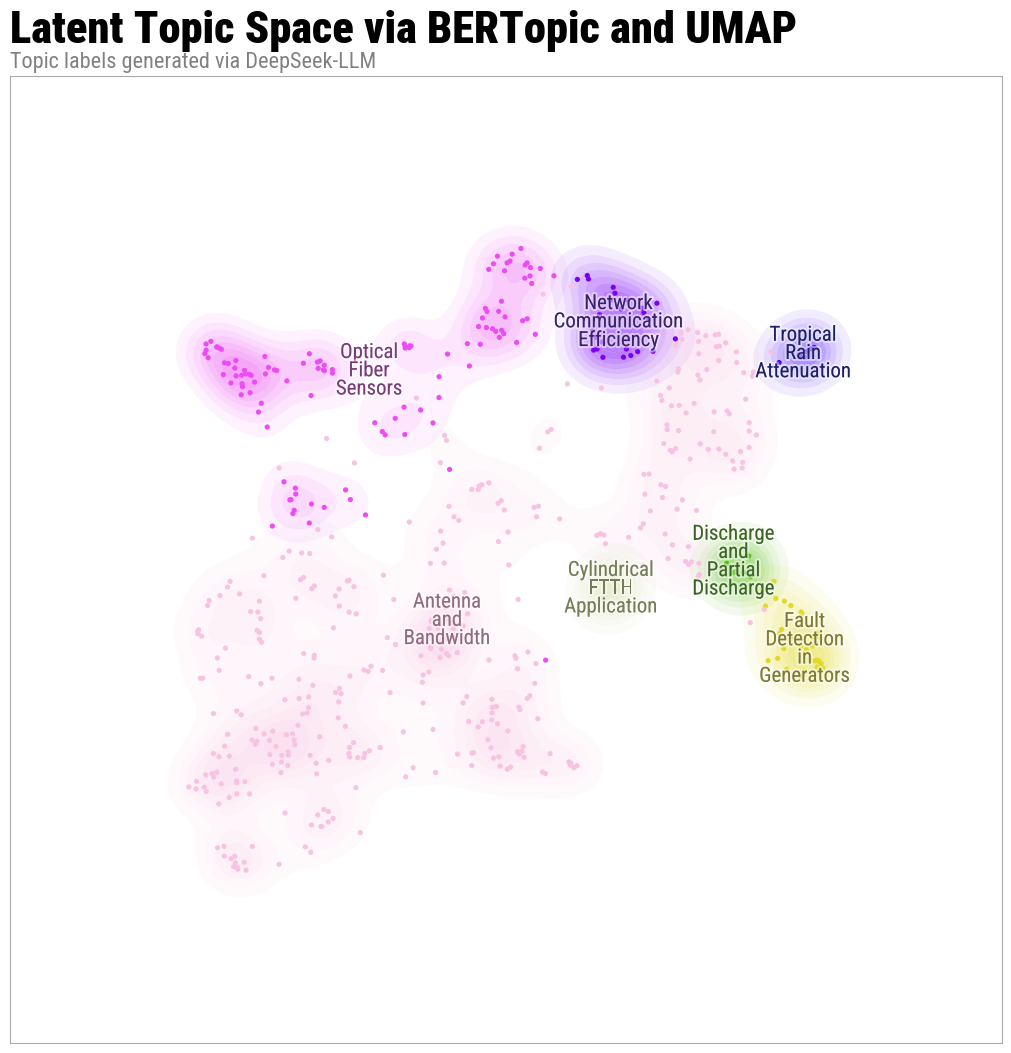

In [ ]:
import datamapplot
import numpy as np
import requests
import PIL
import matplotlib.pyplot as plt
import colorcet

plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = datamapplot.create_plot(
    reduced_embeddings,
    all_labels,
    label_font_size=15,
    title="Latent Topic Space via BERTopic and UMAP",
    sub_title="Topic labels generated via DeepSeek-LLM",
    label_wrap_width=10,
    label_over_points=True,
    dynamic_label_size=True,
    max_font_size=36,
    min_font_size=4,
    min_font_weight=100,
    max_font_weight=1000,
    font_family="Roboto Condensed",
    cmap=colorcet.cm.CET_C2,

)
fig.savefig("/content/drive/MyDrive/[JMoe] Modelagem/plot_latent_topic1.png", bbox_inches="tight")
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


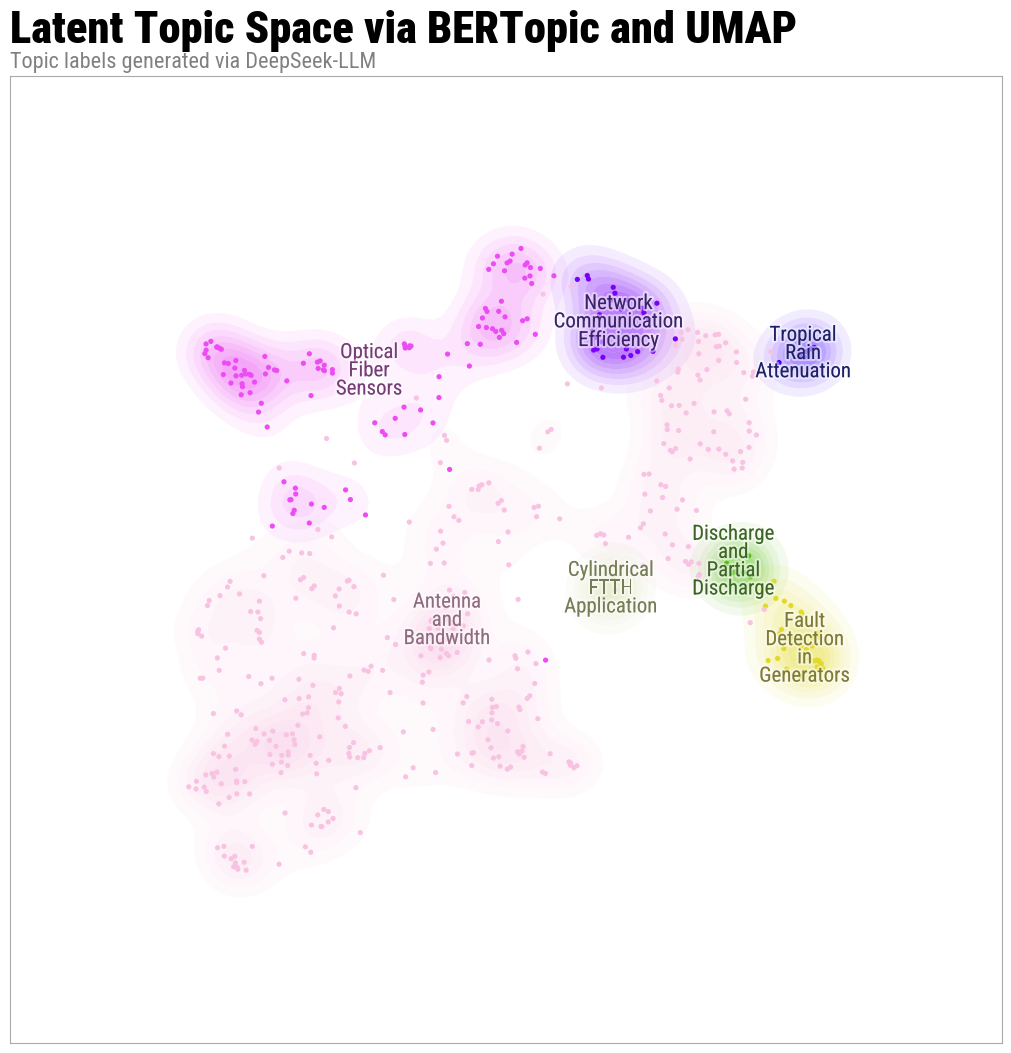

In [ ]:
import datamapplot
import numpy as np
import requests
import PIL
import matplotlib.pyplot as plt
import colorcet

plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = datamapplot.create_plot(
    reduced_embeddings,
    all_labels,
    label_font_size=15,
    title="Latent Topic Space via BERTopic and UMAP",
    sub_title="Topic labels generated via DeepSeek-LLM",
    label_wrap_width=10,
    label_over_points=True,
    dynamic_label_size=True,
    max_font_size=36,
    min_font_size=4,
    min_font_weight=100,
    max_font_weight=1000,
    font_family="Roboto Condensed",
    cmap=colorcet.cm.CET_C2,

)
# fig.savefig("/content/drive/MyDrive/[JMoe] Modelagem/plot_latent_topic3.png", bbox_inches="tight")
plt.show()

Calculating medoids: 100%|██████████| 7/7 [00:06<00:00,  1.09it/s]


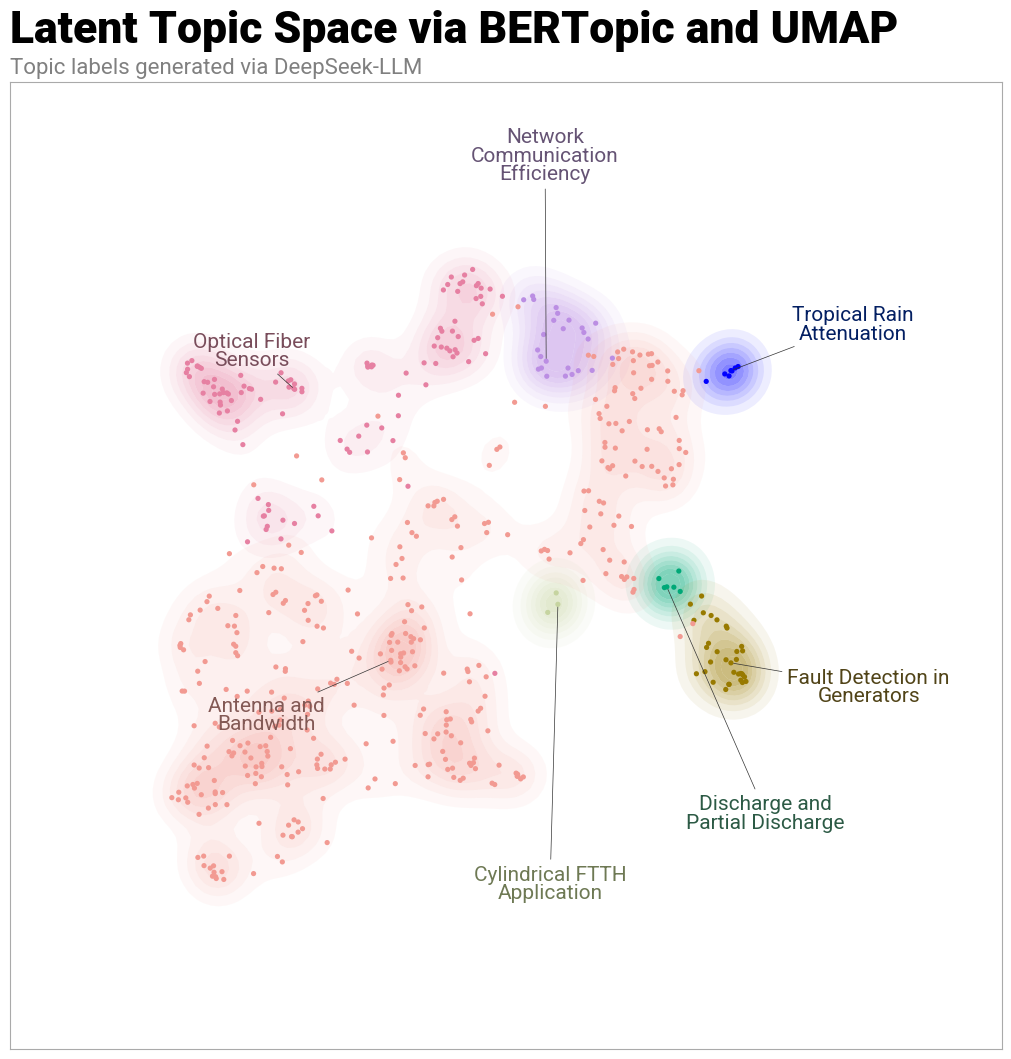

In [ ]:
import datamapplot

plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = datamapplot.create_plot(
    reduced_embeddings,
    all_labels,
    label_font_size=15,
    title="Latent Topic Space via BERTopic and UMAP",
    sub_title="Topic labels generated via DeepSeek-LLM",
    label_wrap_width=20,
    use_medoids=True
)

fig.savefig("/content/drive/MyDrive/[JMoe] Modelagem/plot_latent_topic_medoids2.png", bbox_inches="tight")
plt.show()

Calculating medoids: 100%|██████████| 7/7 [00:00<00:00, 1061.70it/s]


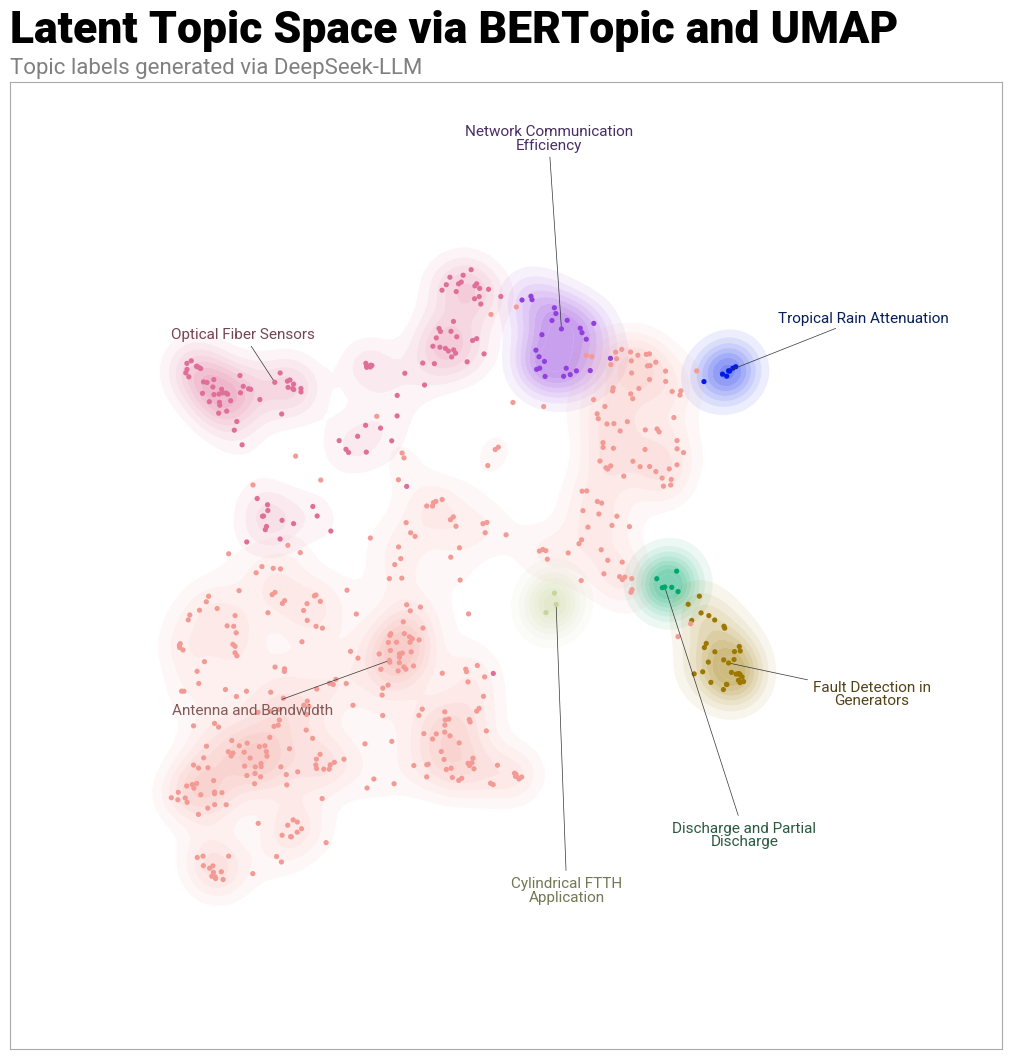

In [ ]:
import datamapplot

plt.rcParams['savefig.bbox'] = 'tight'

fig, ax = datamapplot.create_plot(
    reduced_embeddings,
    all_labels,
    label_font_size=11,
    title="Latent Topic Space via BERTopic and UMAP",
    sub_title="Topic labels generated via DeepSeek-LLM",
    label_wrap_width=27,
    use_medoids=True
)

fig.savefig("/content/drive/MyDrive/[JMoe] Modelagem/plot_latent_topic_medoids.png", bbox_inches="tight")
plt.show()

In [ ]:
# topic_model.visualize_documents(df_unlabeled["text"].tolist(), reduced_embeddings=reduced_embeddings,
#                                 hide_document_hover=True, hide_annotations=True)

## Topic group by year

In [ ]:
import plotly.graph_objects as go
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [ ]:
# count Topic by year
topic_year_counts = df_unlabeled.groupby(['year', 'Topic_Label']).size().reset_index(name='Count')

In [ ]:
topic_year_counts

,year,Topic_Label,Count
0,2010,Antenna and Bandwidth,2
1,2010,Cylindrical FTTH Application,1
2,2010,Optical Fiber Sensors,4
3,2011,Antenna and Bandwidth,20
4,2011,Cylindrical FTTH Application,1
...,...,...,...
65,2024,Network Communication Efficiency,1
66,2024,Optical Fiber Sensors,7
67,2025,Antenna and Bandwidth,18
68,2025,Discharge and Partial Discharge,1


## Heatmap of topics per year

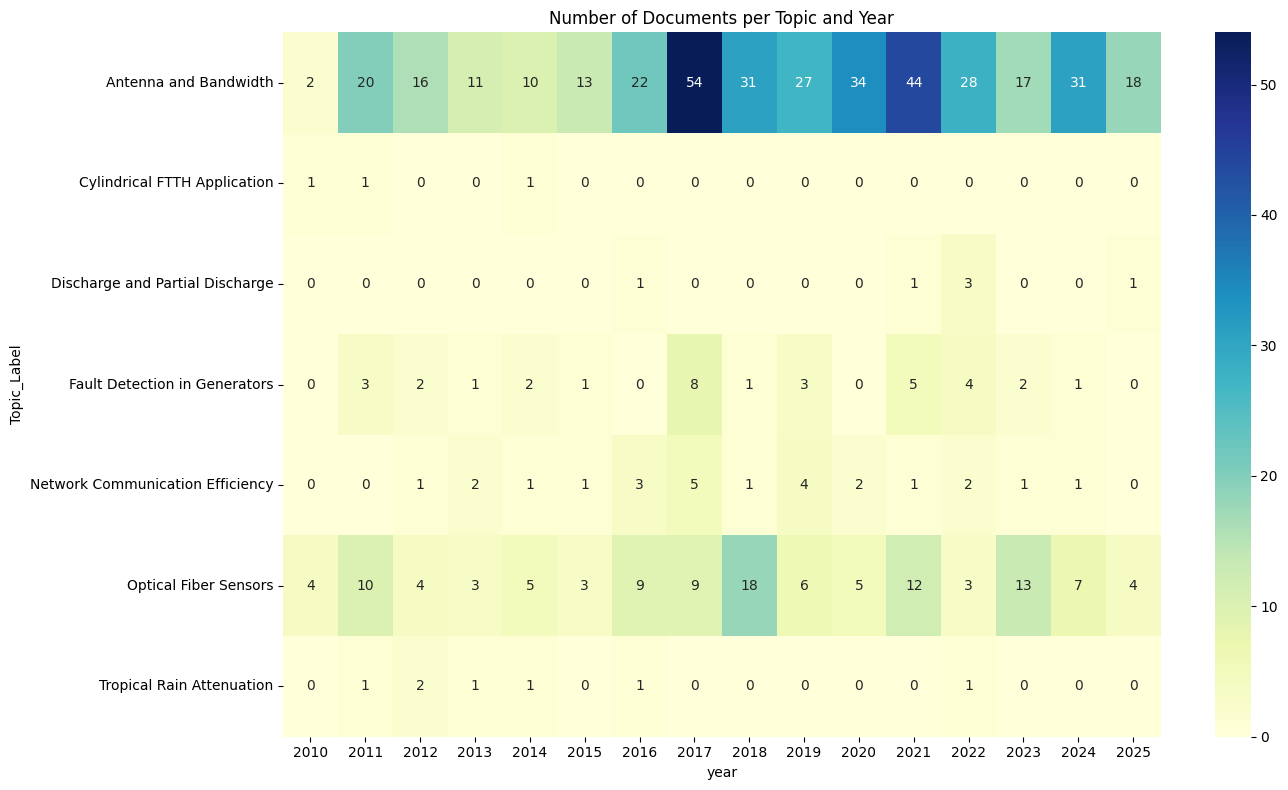

In [ ]:
pivot_table = topic_year_counts.pivot_table(index='Topic_Label', columns='year', values='Count', fill_value=0)
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='g')
plt.title('Number of Documents per Topic and Year')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/[JMoe] Modelagem/topic_year_heatmap.png', dpi=300)
plt.show()

## Line graph (evolution of topics over time)

In [ ]:
years = sorted(df_unlabeled['year'].unique())

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig = px.line(
    topic_year_counts,
    x='year',
    y='Count',
    color='Topic_Label',
    markers=True,
    labels={
        'Count': 'Number of Documents',
        'year': 'Year',
        'Topic_Label': 'Topic'
    },
    title=''
)

fig.update_traces(line=dict(width=3), marker=dict(size=8))

fig.update_layout(
    xaxis=dict(
        title='Year',
        tickmode='array',
        tickvals=sorted(topic_year_counts['year'].unique()),
        tickfont=dict(size=14),
        titlefont=dict(size=16),
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Number of Documents',
        tickfont=dict(size=14),
        titlefont=dict(size=16),
        gridcolor='lightgray'
    ),
    legend=dict(
        title='Topic',
        font=dict(size=13),
        yanchor='top',
        y=1.08,
        xanchor='left',
        x=0,
        orientation='h'
    ),
    plot_bgcolor='rgba(245,245,245,1)',
    paper_bgcolor='rgba(245,245,245,1)',
    height=800,
    width=1700,
    margin=dict(t=50, l=50, r=50, b=50)
)

fig.write_html('/content/drive/MyDrive/[JMoe] Modelagem/topic_year_lines.html')
fig.show()

In [ ]:
import plotly.express as px

fig = px.line(
    topic_year_counts,
    x='year',
    y='Count',
    color='Topic_Label',
    markers=True,
    title='Evolution of Research Topics (2002–2025)',
    labels={'Count': 'Number of Documents', 'year': 'Year', 'Topic_Label': 'Topic'},
    line_shape='linear'
)

fig.update_traces(line=dict(width=2), marker=dict(size=8))

fig.update_layout(
    template='simple_white',
    width=1700,
    height=700,
    font=dict(size=16),
    legend=dict(
        title='',
        font=dict(size=14),
        orientation='v',
        y=1,
        x=1.02,
        xanchor='left',
        yanchor='top'
    ),
    margin=dict(l=60, r=200, t=60, b=60),
    xaxis=dict(
        tickmode='linear',
        tick0=2002,
        dtick=2,
        title='',
        showgrid=True
    ),
    yaxis=dict(
        title='Number of Documents',
        gridcolor='lightgray'
    )
)
fig.write_html('/content/drive/MyDrive/[JMoe] Modelagem/topic_year_lines2.html')
fig.show()


## Overview of topics by year

In [ ]:
df_unlabeled.head()

,_id,year,volume,numero,title,author,palavras_chave,abstract,referencias,link,...,estado,texto_documento_preprocessed,universities_translated,universities,text,Topic,Probability,Topic_Default,Topic_KeyBERT,Topic_Label
0,68a8cad06a09251fb721014d,2025,24,1,A Flexible UHF RFID Respiratory Sensor,"['Araujo, Jéssyca I. L.', 'Serres, Georgina K....",Index Terms\\\\nFlexible tag; Metamaterial-ins...,"In this study, we developed a Radio Frequency ...","[1] M. A. Cretikos, R. Bellomo, K. Hillman, J....",https://www.scielo.br/j/jmoea/a/XHgN4VqNZCD5cC...,...,"[Paraíba, Paraíba, Pisa, Paraíba, Paraíba]",federal university of campina grande; federal ...,Universidade Federal de Campina Grande; Univer...,"['universidade federal de campina grande', 'un...",flexible uhf rfid respiratory sensor develop r...,0,0.822367,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
1,68a8cad36a09251fb721014e,2025,24,1,Proposition for Path Loss Prediction Models wi...,"['Jorge Júnior, Evandro M.', 'Veiga, Antônio C...",Index Terms\\\\nDifferential Evolution; Geneti...,"In this paper, it is presented a general optim...","[1] N. Faruk, S. I. Popoola, N. T. Surajudeen-...",https://www.scielo.br/j/jmoea/a/XFZhWqy65ZzgzZ...,...,"[Minas Gerais, Minas Gerais, Minas Gerais]",universidade federal de uberlandia; universida...,Universidade Federal de Uberlandia; Universida...,"['universidade federal de uberlandia', 'univer...",proposition path loss prediction model inclusi...,0,1.0,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
2,68a8cad66a09251fb721014f,2025,24,1,A 1D-FDM Transmission Line Model for Partial D...,"['Oliveira, Rodrigo M. S. de', 'Lopes, Nathan ...",Index Terms\\\\nEffective Electrical Conductiv...,"In this paper, we present a novel numerical mo...","[1] A. Haddad and D. F. Warne, Eds., Advances ...",https://www.scielo.br/j/jmoea/a/WQxvPr4GjWVKVw...,...,"[Brazil, Brazil]",federal university of para; ufpa itec; eletrob...,Universidade Federal do Pará; Universidade Fed...,"['universidade federal do para', 'universidade...",fdm transmission line model partial discharge ...,5,1.0,5_discharge_pore_partial_sound,"[discharge dielectric, discharge current, air ...",Discharge and Partial Discharge
3,68a8cad86a09251fb7210150,2025,24,1,Assessment of Planar Transmission Line with St...,"['Fonseca, Daniel A. B.', 'Costa, Luís G. da S...",Index Terms\\\\nPlanar transmission line; powe...,This study investigates the effectiveness of e...,"[1] D. K. Mahanta and O. Andrew, “Transformer ...",https://www.scielo.br/j/jmoea/a/vr67fPZqgtyFVb...,...,"[Minas Gerais, Minas Gerais, Minas Gerais, Min...",universidade federal de juiz de fora; universi...,Universidade Federal de Juiz de Fora; Universi...,"['universidade federal de juiz de fora', 'univ...",assessment planar transmission line stub measu...,0,0.137378,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
4,68a8cada6a09251fb7210151,2025,24,1,Space-fed Array Variations of E-shape and U-sl...,"['Deshmukh, Amit A.', 'Parvez, Adil', 'Chavali...",Index Terms\\\\nBroadband High gain microstrip...,Space-fed array comprising of E-shape or U-slo...,"[1] G. Kumar, K. P. Ray, Broadband Microstrip ...",https://www.scielo.br/j/jmoea/a/Nkr93SPpvfsMLP...,...,"[India, India, India, India]",dwarkadas jivanlal sanghvi college of engineer...,Faculdade de Engenharia Dwarkadas Jivanlal San...,['faculdade de engenharia dwarkadas jivanlal s...,space feed array variation shape slot cut rect...,0,0.465442,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth


In [ ]:
df_unlabeled.groupby(['Topic', 'Topic_Default', 'Topic_Label']).size().reset_index(name='count')

,Topic,Topic_Default,Topic_Label,count
0,0,0_antenna_band_ghz_frequency,Antenna and Bandwidth,378
1,1,1_optical_fiber_sensor_base,Optical Fiber Sensors,115
2,2,2_motor_magnetic_fault_generator,Fault Detection in Generators,33
3,3,3_network_channel_mobile_communication,Network Communication Efficiency,25
4,4,4_attenuation_rain_tropical_climate,Tropical Rain Attenuation,7
5,5,5_discharge_pore_partial_sound,Discharge and Partial Discharge,6
6,6,6_bem_abc_cfs_lift,Cylindrical FTTH Application,3


In [ ]:
for year in sorted(df_unlabeled['year'].unique()):
    year_topics = topic_year_counts[topic_year_counts['year'] == year]
    if not year_topics.empty:
        print(f"\nYear: {year} - {len(year_topics)} topics")
        for _, row in year_topics.sort_values('Count', ascending=False).iterrows():
            print(f"  • {row['Topic_Label']}: {row['Count']} documents")


Year: 2010 - 3 topics
  • Optical Fiber Sensors: 4 documents
  • Antenna and Bandwidth: 2 documents
  • Cylindrical FTTH Application: 1 documents

Year: 2011 - 5 topics
  • Antenna and Bandwidth: 20 documents
  • Optical Fiber Sensors: 10 documents
  • Fault Detection in Generators: 3 documents
  • Cylindrical FTTH Application: 1 documents
  • Tropical Rain Attenuation: 1 documents

Year: 2012 - 5 topics
  • Antenna and Bandwidth: 16 documents
  • Optical Fiber Sensors: 4 documents
  • Fault Detection in Generators: 2 documents
  • Tropical Rain Attenuation: 2 documents
  • Network Communication Efficiency: 1 documents

Year: 2013 - 5 topics
  • Antenna and Bandwidth: 11 documents
  • Optical Fiber Sensors: 3 documents
  • Network Communication Efficiency: 2 documents
  • Fault Detection in Generators: 1 documents
  • Tropical Rain Attenuation: 1 documents

Year: 2014 - 6 topics
  • Antenna and Bandwidth: 10 documents
  • Optical Fiber Sensors: 5 documents
  • Fault Detection in Gener

## Sankey Diagram

In [ ]:
def extract_topic_data_from_text(text):
    """Extrai dados de tópicos do texto de saída"""
    data = []

    # Padrão para capturar informações do ano e tópicos
    year_pattern = r"Ano: (\d+) - (\d+) tópicos"
    topic_pattern = r"• ([^:]+): (\d+) documentos"

    current_year = None

    for line in text.strip().split("\n"):

        year_match = re.search(year_pattern, line)
        if year_match:
            current_year = int(year_match.group(1))
            continue


        topic_match = re.search(topic_pattern, line)
        if topic_match and current_year:
            topic = topic_match.group(1).strip()
            count = int(topic_match.group(2))
            data.append({
                "year": current_year,
                "topic": topic,
                "count": count
            })

    return pd.DataFrame(data)

In [ ]:
# df = extract_topic_data_from_text(text_output)

In [ ]:
def topics_to_df(df_filtered, topic_year_counts):
    """
    Função simplificada que converte diretamente
    os dados de tópicos em um DataFrame estruturado
    """
    data = []

    # Processar os dados por ano
    for year in sorted(df_filtered['year'].unique()):
        year_topics = topic_year_counts[topic_year_counts['year'] == year]

        if not year_topics.empty:
            # Processar cada tópico deste ano
            for _, row in year_topics.sort_values('Count', ascending=False).iterrows():
                topic = row['Topic_Label']
                count = row['Count']

                # Adicionar ao DataFrame
                data.append({
                    "year": year,
                    "topic": topic,
                    "count": count
                })

    # Criar e retornar o DataFrame
    import pandas as pd
    return pd.DataFrame(data)

df = topics_to_df(df_unlabeled, topic_year_counts)

In [ ]:
df = topic_year_counts[['year', 'Topic_Label', 'Count']]
df.columns = ['year', 'topic', 'count']

print(f"Total de registros extraídos: {len(df)}")
df.head()

Total de registros extraídos: 70


,year,topic,count
0,2010,Antenna and Bandwidth,2
1,2010,Cylindrical FTTH Application,1
2,2010,Optical Fiber Sensors,4
3,2011,Antenna and Bandwidth,20
4,2011,Cylindrical FTTH Application,1


# Visualization BERTopic

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,KeyBERT,LLM_Gemma,LLM_DeepSeek,Representative_Docs
0,0,378,0_antenna_band_ghz_frequency,"[antenna, band, ghz, frequency, design, propos...","[microstrip, propose antenna, patch antenna, w...",[- Wideband Antennas\n- Microstrip Antennas\n-...,"[Antenna and Bandwidth, , , , , , , , , ]",[new miniaturize low profile stable dual band ...
1,1,115,1_optical_fiber_sensor_base,"[optical, fiber, sensor, base, system, analysi...","[optical fiber, refractive index, fiber bragg,...",[- Optical Sensors\n- Fiber Sensors\n- Sensor ...,"[Optical Fiber Sensors, , , , , , , , , ]",[computational modeling magnetic field optical...
2,2,33,2_motor_magnetic_fault_generator,"[motor, magnetic, fault, generator, hysteresis...","[synchronous generator, magnet synchronous, fa...",[1. Motor and Generator Faults\n2. Magnetic an...,"['Fault Detection in Generators', , , , , , , ...",[experimental loss segregation solid rotor ind...
3,3,25,3_network_channel_mobile_communication,"[network, channel, mobile, communication, ofdm...","[ofdm, broadband power, mobile radio, mac prot...",[- Wireless Network Design\n- Network Protocol...,"[Network Communication Efficiency, , , , , , ,...",[reliable energy efficient multilayer mechanis...
4,4,7,4_attenuation_rain_tropical_climate,"[attenuation, rain, tropical, climate, terrest...","[rain attenuation, differential rain, measured...",[B: Rain Attenuation Prediction\nC: Tropical R...,"[Tropical Rain Attenuation, , , , , , , , , ]",[statistical modeling rain attenuation tropica...
5,5,6,5_discharge_pore_partial_sound,"[discharge, pore, partial, sound, lightning, d...","[discharge dielectric, discharge current, air ...",[- Discharge and Sound Waves\n- Partial Discha...,"[Discharge and Partial Discharge, , , , , , , ...",[spectral localization multiple partial discha...
6,6,3,6_bem_abc_cfs_lift,"[bem, abc, cfs, lift, preconditioner, macroben...","[cylindrical cfs, preconditioner base, level p...",[- Base Lift FEM\n- Preconditioner Base\n- Lev...,"[""Cylindrical FTTH Application"", , , , , , , ,...",[efficient level preconditioner base lift fem ...


In [ ]:
custom_labels = topic_model.get_topics(full=True)["KeyBERT"]

In [ ]:
custom_labels

{-1: [('propose antenna', np.float32(0.5820202)),
  ('microstrip', np.float32(0.5335621)),
  ('metamaterial', np.float32(0.47960192)),
  ('antenna', np.float32(0.41522878)),
  ('wideband', np.float32(0.401173)),
  ('waveguide', np.float32(0.38197553)),
  ('monopole', np.float32(0.36695868)),
  ('dielectric', np.float32(0.3629816)),
  ('impedance', np.float32(0.36263943)),
  ('ghz', np.float32(0.35543048))],
 0: [('microstrip', np.float32(0.5760958)),
  ('propose antenna', np.float32(0.54053485)),
  ('patch antenna', np.float32(0.52990943)),
  ('wideband', np.float32(0.44131172)),
  ('dual band', np.float32(0.42573732)),
  ('antenna', np.float32(0.40329242)),
  ('impedance', np.float32(0.3950563)),
  ('ghz', np.float32(0.3502962)),
  ('dielectric', np.float32(0.3479811)),
  ('ghz ghz', np.float32(0.31717062))],
 1: [('optical fiber', np.float32(0.41478783)),
  ('refractive index', np.float32(0.39990553)),
  ('fiber bragg', np.float32(0.39323556)),
  ('bragg grating', np.float32(0.328102

In [ ]:
df_unlabeled.head()

,author,year,title,abstract,text,Topic,Topic_Label,Topic_KeyBERT,Topic_Default
0,AICPA,2020,AICPA Privacy Management Framework,The Privacy Management Framework (PMF) can be ...,aicpa privacy management framework privacy man...,10,Privacy Framework & Business Value,"['data privacy', 'consumer data', 'personal da...",10_brand_pet_personal_happiness
1,{Data and Marketing Association},2022,Code of Conduct of the Data and Marketing,The DMA Code is an ethical framework that sets...,code conduct data market dma code ethic framew...,0,Customer Relationship Management,"['management crm', 'crm', 'customer relationsh...",0_crm_customer_relationship_management
2,{European Commission},2022,Proposal for a Regulation of the European Parl...,This legislative initiative will aim at facili...,proposal regulation european parliament counci...,7,Data Protection and Security Management,"['data security', 'data protection', 'data com...",7_protection_security_data_digital
3,{Federal Trade Commission},2012,The 2012 Federal Trade Commission Privacy Fram...,"In today's world of smart phones, smart grids,...",federal trade commission privacy framework tod...,10,Privacy Framework & Business Value,"['data privacy', 'consumer data', 'personal da...",10_brand_pet_personal_happiness
4,GDPR.EU,2023,GDPR: Complete Guide to GDPR Compliance,The General Data Protection Regulation (GDPR) ...,gdpr complete guide gdpr compliance general da...,4,GDPR Compliance in Software Development,"['gdpr compliance', 'regulation gdpr', 'gdpr',...",4_gdpr_compliance_regulation_protection


In [ ]:
df_unlabeled['Topic'].nunique()

7

In [ ]:
df_unlabeled['Topic_Label'].value_counts()

,count
Topic_Label,
Antenna and Bandwidth,378
Optical Fiber Sensors,115
Fault Detection in Generators,33
Network Communication Efficiency,25
Tropical Rain Attenuation,7
Discharge and Partial Discharge,6
Cylindrical FTTH Application,3


In [ ]:
df_unlabeled['Topic_KeyBERT'].value_counts()

,count
Topic_KeyBERT,
"[microstrip, propose antenna, patch antenna, wideband, dual band, antenna, impedance, ghz, dielectric, ghz ghz]",378
"[optical fiber, refractive index, fiber bragg, bragg grating, surface plasmon, optical network, sensor, refractive, plasmon, photonic crystal]",115
"[synchronous generator, magnet synchronous, fault current, induction motor, stator winding, electrical, magnetic gear, load emf, power plant, emf]",33
"[ofdm, broadband power, mobile radio, mac protocol, wlan, wireless, mimo, massive mimo, access network, line communication]",25
"[rain attenuation, differential rain, measured rain, attenuation tropical, prediction rain, wet antenna, attenuation prediction, rain, terrestrial link, antenna attenuation]",7
"[discharge dielectric, discharge current, air ionization, calculate discharge, ionized air, partial discharge, conductivity ionized, discharge occur, correlate discharge, electric field]",6
"[cylindrical cfs, preconditioner base, level preconditioner, core pcf, analysis cylindrical, cfs pml, pcf ftth, volume simulation, preconditioner, frequency domain]",3


In [ ]:
df_unlabeled[['Topic', 'Topic_Label', 'Topic_KeyBERT']].drop_duplicates().sort_values('Topic').reset_index(drop=True)

TypeError: unhashable type: 'list'

In [ ]:
top10_per_topic = df_unlabeled.groupby('Topic_Label').head(5).reset_index(drop=True)

In [ ]:
top10_per_topic = (
    df_unlabeled.groupby('Topic_Label', group_keys=False)
    .apply(lambda g: g.sample(n=5, random_state=42) if len(g) >= 5 else g)
    .reset_index(drop=True)
)


/tmp/ipython-input-1461182832.py:3: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [ ]:
top10_per_topic.head()

,_id,year,volume,numero,title,author,palavras_chave,abstract,referencias,link,...,estado,texto_documento_preprocessed,universities_translated,universities,text,Topic,Probability,Topic_Default,Topic_KeyBERT,Topic_Label
0,68a8e1e3884bbdaa3a881b5e,2016,15,2,Signal Processing Technique for Time Domain Me...,"['Nobre, Isabela M.', 'Nicolini, Julio L.', 'G...",Instrumentation; Microwave; Signal Processing;...,"In this paper, a simple and accurate technique...","1 K. Kurokawa, “Power waves and the scattering...",https://www.scielo.br/j/jmoea/a/8JQCZ3g6N9LbjT...,...,"[Morocco, Morocco, Morocco, Morocco]",pontifical catholic university of rio de janei...,Universidade Católica Pontifical do Rio de Jan...,['universidade catolica pontifical do rio de j...,signal processing technique time domain measur...,0,0.536566,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
1,68a8e3d7b925f4c21fdd1514,2013,12,1,Microstrip feed spanner shape monopole antenna...,"['Mandal, Tapan', 'Das, Santanu']",NaN,NaN,NaN,https://www.scielo.br/j/jmoea/a/JSgpFLSzLLckTC...,...,[],government college of engineering and textile ...,Faculdade de Engenharia e Tecnologia do Govern...,['faculdade de engenharia tecnologia do gover...,microstrip feed spanner shape monopole antenna...,0,0.83649,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
2,68a8e3805a5f18b2df4e30b2,2014,13,1,Rectangular notch loaded dual band annular rin...,"['Singh, Prabhakar']",NaN,NaN,NaN,https://www.scielo.br/j/jmoea/a/KJZL33zCNLcBCn...,...,[],galgotias university,Universidade de Galgotias,['universidade de galgotias'],rectangular notch load dual band annular ring ...,0,0.855911,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
3,68a8d672500e04718a68c8f9,2020,19,1,Sixteenth-Mode Substrate-Integrated-Waveguide ...,"['Siabah, Fatima Zohra', 'Grine, Farouk', 'Ben...",Index Terms\\\\nChemical sensor; Passive micro...,"In this work, a new concept of planar resonato...","[1] Y. Huang, K. M. Hotopp, B. C. Dian and W. ...",https://www.scielo.br/j/jmoea/a/FDH4rmKZfcRBkJ...,...,"[Johor, Johor, Johor, Johor]",universite de constantine ; universite de cons...,Universidade de Constantino; Universidade de C...,"['universidade de constantino', 'universidade ...",sixteenth mode substrate integrate waveguide s...,0,0.246596,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth
4,68a8d1edbbe0df8f40dc87ff,2023,22,1,Coexistence Analysis Between IMT-2020 and AES ...,"['Alexandre, Luciano Camilo', 'Linhares, Agost...",Index Terms\\\\n5G; AES; coexistence; IMT and ...,This paper is regarding the statistical coexis...,"1 ITU, “Radio Regulations,” ITU, vol. 1, 2020....",https://www.scielo.br/j/jmoea/a/5S7jCLD667XTtV...,...,"[Minas Gerais, Minas Gerais, Minas Gerais, Min...",national institute of telecommunications; nati...,Instituto Nacional de Telecomunicações; Agênci...,"['instituto nacional de telecomunicacoes', 'ag...",coexistence analysis imt aes operate band fina...,0,0.627256,0_antenna_band_ghz_frequency,"[microstrip, propose antenna, patch antenna, w...",Antenna and Bandwidth


In [ ]:
top10_per_topic[['author','year', 'title','Topic']].drop_duplicates().sort_values('Topic').reset_index(drop=True)

,author,year,title,Topic
0,"['Nobre, Isabela M.', 'Nicolini, Julio L.', 'G...",2016,Signal Processing Technique for Time Domain Me...,0
1,"['Mandal, Tapan', 'Das, Santanu']",2013,Microstrip feed spanner shape monopole antenna...,0
2,"['Singh, Prabhakar']",2014,Rectangular notch loaded dual band annular rin...,0
3,"['Siabah, Fatima Zohra', 'Grine, Farouk', 'Ben...",2020,Sixteenth-Mode Substrate-Integrated-Waveguide ...,0
4,"['Alexandre, Luciano Camilo', 'Linhares, Agost...",2023,Coexistence Analysis Between IMT-2020 and AES ...,0
5,"['Sisnando, Anderson Dourado', 'Esquerre, Vita...",2020,Inverse Design of Tapers by Bio-Inspired Algor...,1
6,"['Souza, Romildo Henrique de', 'Coutinho, Olym...",2017,An Analytical Solution for Fiber Optic Links w...,1
7,"['Bonani, Luiz Henrique']",2016,Modeling an Optical Network Operating with Hyb...,1
8,"['Bastida, Gabriel C.', 'Rocha, Helder R. de O...",2024,Optimization of Very Short Multi-Pump Discrete...,1
9,"['Silva, Sergio A.', 'Bastos-Filho, Carmelo J....",2024,Strategy for Resource Allocation in Elastic Op...,1


In [ ]:
# or use one of the other topic representations, like KeyBERTInspired
keybert_topic_labels={topic: ' | '.join(list(zip(*values))[0][:3]) for topic, values in topic_model.topic_aspects_['KeyBERT'].items()}
topic_model.set_topic_labels(keybert_topic_labels)

In [ ]:
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,KeyBERT,LLM_Gemma,LLM_DeepSeek,Representative_Docs
0,0,378,0_antenna_band_ghz_frequency,microstrip | propose antenna | patch antenna,"[antenna, band, ghz, frequency, design, propos...","[microstrip, propose antenna, patch antenna, w...",[- Wideband Antennas\n- Microstrip Antennas\n-...,"[Antenna and Bandwidth, , , , , , , , , ]",[new miniaturize low profile stable dual band ...
1,1,115,1_optical_fiber_sensor_base,optical fiber | refractive index | fiber bragg,"[optical, fiber, sensor, base, system, analysi...","[optical fiber, refractive index, fiber bragg,...",[- Optical Sensors\n- Fiber Sensors\n- Sensor ...,"[Optical Fiber Sensors, , , , , , , , , ]",[computational modeling magnetic field optical...
2,2,33,2_motor_magnetic_fault_generator,synchronous generator | magnet synchronous | f...,"[motor, magnetic, fault, generator, hysteresis...","[synchronous generator, magnet synchronous, fa...",[1. Motor and Generator Faults\n2. Magnetic an...,"['Fault Detection in Generators', , , , , , , ...",[experimental loss segregation solid rotor ind...
3,3,25,3_network_channel_mobile_communication,ofdm | broadband power | mobile radio,"[network, channel, mobile, communication, ofdm...","[ofdm, broadband power, mobile radio, mac prot...",[- Wireless Network Design\n- Network Protocol...,"[Network Communication Efficiency, , , , , , ,...",[reliable energy efficient multilayer mechanis...
4,4,7,4_attenuation_rain_tropical_climate,rain attenuation | differential rain | measure...,"[attenuation, rain, tropical, climate, terrest...","[rain attenuation, differential rain, measured...",[B: Rain Attenuation Prediction\nC: Tropical R...,"[Tropical Rain Attenuation, , , , , , , , , ]",[statistical modeling rain attenuation tropica...
5,5,6,5_discharge_pore_partial_sound,discharge dielectric | discharge current | air...,"[discharge, pore, partial, sound, lightning, d...","[discharge dielectric, discharge current, air ...",[- Discharge and Sound Waves\n- Partial Discha...,"[Discharge and Partial Discharge, , , , , , , ...",[spectral localization multiple partial discha...
6,6,3,6_bem_abc_cfs_lift,cylindrical cfs | preconditioner base | level ...,"[bem, abc, cfs, lift, preconditioner, macroben...","[cylindrical cfs, preconditioner base, level p...",[- Base Lift FEM\n- Preconditioner Base\n- Lev...,"[""Cylindrical FTTH Application"", , , , , , , ,...",[efficient level preconditioner base lift fem ...


In [ ]:
topic_model.visualize_barchart(top_n_topics=20, n_words=10, height=300)

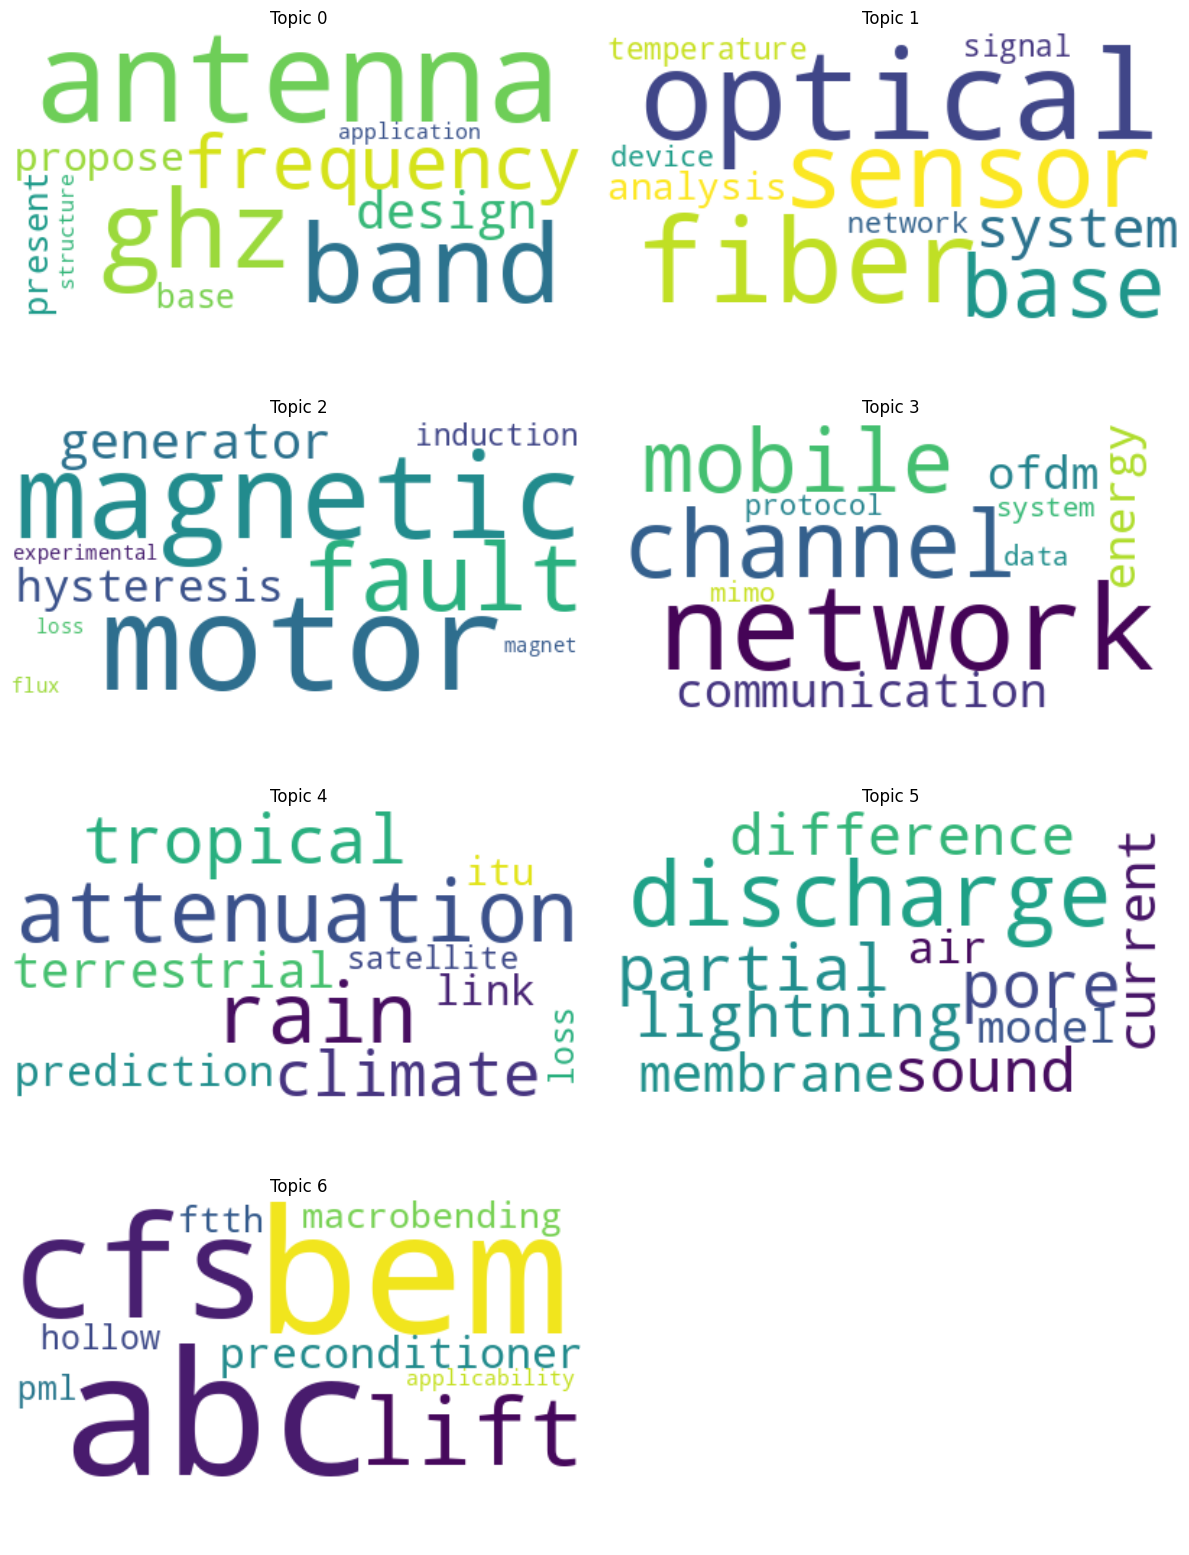

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

topics = topic_model.get_topics()
top_n = 7
cols = 2
rows = (top_n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))

for i, topic_id in enumerate(range(top_n)):
    row = i // cols
    col = i % cols
    ax = axes[row, col] if rows > 1 else axes[col]

    if topic_id in topics:
        words = dict(topics[topic_id])
        wordcloud = WordCloud(width=400, height=200, background_color='white').generate_from_frequencies(words)
        ax.imshow(wordcloud, interpolation='bilinear')
        ax.set_title(f"Topic {topic_id}", fontsize=12)
        ax.axis("off")

if top_n % cols != 0:
    axes[-1, -1].axis("off")

plt.tight_layout()
plt.show()
